In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import os
import re

In [2]:
# Load the Drive helper and mount
from google.colab import drive
# This will prompt for authorization.
drive.mount('/content/drive')

# Change to assignment directory
import os
os.chdir('/content/drive/MyDrive/')

Mounted at /content/drive


In [3]:
new_data2 = pd.read_csv("AGES_absorbances.csv", low_memory=False) #/content/
new_data2['Depth'] = round(new_data2['Depth'], 0)

## Filter data

In [4]:
import re
spectra_cols = [c for c in new_data2.columns
                if re.match(r'^[SF]\d', str(c))]

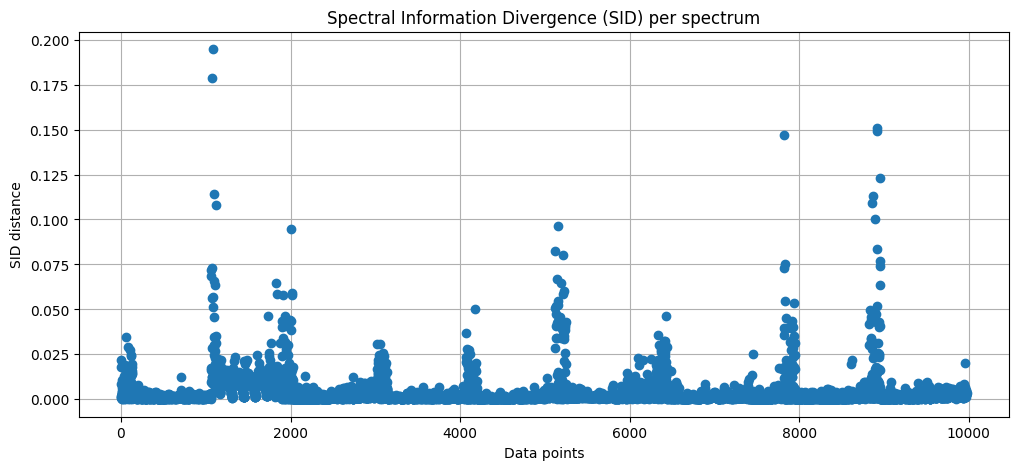

In [5]:
X = new_data2[spectra_cols].values

# 1. Ensure non-negative and normalize each spectrum to sum=1
X_pos = np.clip(X, 0, None)  # set negative values to 0
X_norm = X_pos / X_pos.sum(axis=1, keepdims=True)

# 2. Function to compute SID between two spectra
def sid(x, y):
    # small epsilon to avoid log(0)
    eps = 1e-10
    x = x + eps
    y = y + eps
    return np.sum(x * np.log(x / y)) + np.sum(y * np.log(y / x))

# 3. Compute one-dimensional SID distance for each spectrum
# Compute the mean spectrum once
mean_spectrum = X_norm.mean(axis=0)

# Then compute SID for each spectrum against the mean
sid_scores = np.zeros(X_norm.shape[0])
for i in range(X_norm.shape[0]):
    sid_scores[i] = np.sum(X_norm[i] * np.log((X_norm[i] + 1e-10) / mean_spectrum)) + \
                    np.sum(mean_spectrum * np.log((mean_spectrum + 1e-10) / X_norm[i]))

# 4. Plot SID distances
plt.figure(figsize=(12, 5))
plt.plot(np.arange(1, X_norm.shape[0]+1), sid_scores, 'o')
plt.xlabel("Data points")
plt.ylabel("SID distance")
plt.title("Spectral Information Divergence (SID) per spectrum")
plt.grid(True)
plt.show()

In [6]:
# Threshold for SID
sid_threshold = 0.02

# Select spectra below the threshold
sid_filtered_data2 = new_data2[sid_scores <= sid_threshold].copy()

# Optional: check how many rows were removed
print(f"Original rows: {new_data2.shape[0]}")
print(f"Filtered rows (SID ≤ 0.02): {sid_filtered_data2.shape[0]}")
print(f"Removed outliers (SID > 0.02): {new_data2.shape[0] - sid_filtered_data2.shape[0]}")

Original rows: 9974
Filtered rows (SID ≤ 0.02): 9767
Removed outliers (SID > 0.02): 207


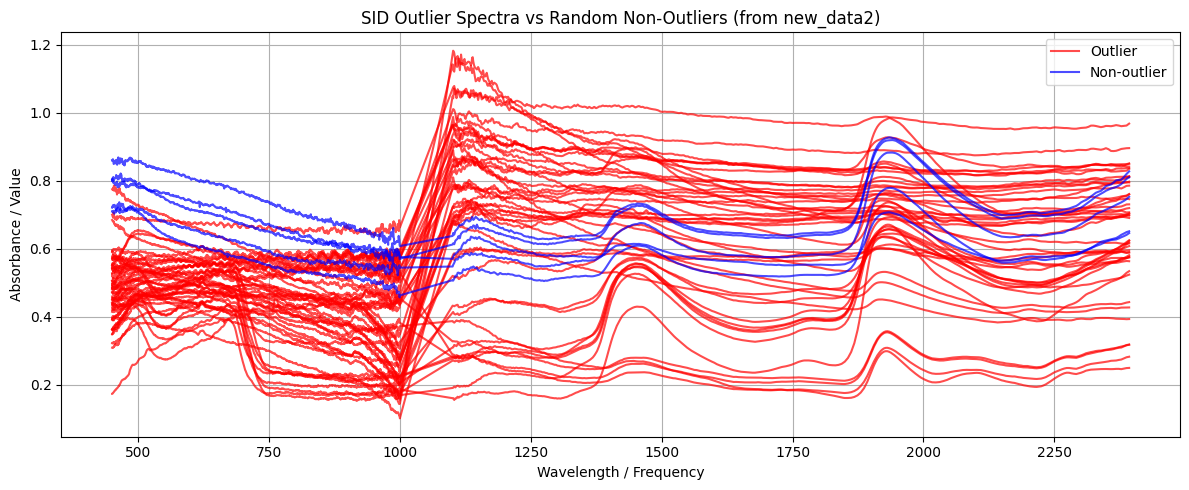

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import re

# spectral columns
spectral_cols = [c for c in new_data2.columns if re.match(r'^[SF]\d', str(c))]

# wavebands (numeric part of spectral columns)
wavebands = [float(c[1:]) for c in spectral_cols]

# SID threshold
sid_threshold = 0.05

# Identify outliers and non-outliers
outlier_idx = np.where(sid_scores > sid_threshold)[0]
non_outlier_idx = np.where(sid_scores <= sid_threshold)[0]

# Select 5 random non-outlier spectra
np.random.seed(42)
random_non_outliers = np.random.choice(non_outlier_idx, size=min(5, len(non_outlier_idx)), replace=False)

# Plot outliers in red, random non-outliers in blue
plt.figure(figsize=(12, 5))

# plot outliers
for idx in outlier_idx:
    plt.plot(wavebands, new_data2.loc[idx, spectral_cols], color='red', alpha=0.7,
             label='Outlier' if idx == outlier_idx[0] else "")

# plot random non-outliers
for idx in random_non_outliers:
    plt.plot(wavebands, new_data2.loc[idx, spectral_cols], color='blue', alpha=0.7,
             label='Non-outlier' if idx == random_non_outliers[0] else "")

plt.xlabel("Wavelength / Frequency")
plt.ylabel("Absorbance / Value")
plt.title("SID Outlier Spectra vs Random Non-Outliers (from new_data2)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Smoothing spectra

Optimal Window Size: 11


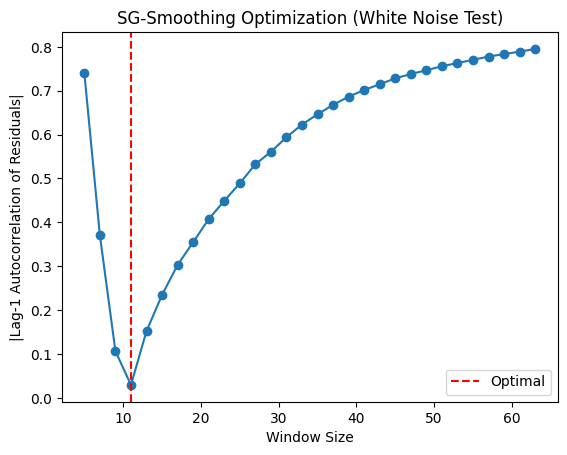

In [7]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

def calculate_lag1_autocorr(series):
    """Calculates the correlation of a signal with its own 1-step lag."""
    if len(series) < 2: return 0
    return np.corrcoef(series[:-1], series[1:])[0, 1]

def optimize_savgol(spectra, window_range=range(5, 51, 2), polyorder=2):
    """Finds the window size that minimizes residual Lag-1 autocorrelation."""
    results = []

    for w in window_range:
        # 1. Apply filter
        smoothed = savgol_filter(spectra, window_length=w, polyorder=polyorder)

        # 2. Calculate residuals (the noise removed)
        residuals = spectra - smoothed

        # 3. Measure autocorrelation of residuals
        # We want this to be near 0 (white noise)
        ac1 = calculate_lag1_autocorr(residuals)
        results.append((w, abs(ac1)))

    # Best window size has AC1 closest to 0
    best_w = min(results, key=lambda x: x[1])[0]
    return best_w, results

# --- Example Usage ---
# Assuming 'X' is a single spectrum array
spectra_cols = [c for c in sid_filtered_data2.columns if re.match(r'^[SF]\d', str(c))]
spectra = np.array(sid_filtered_data2[spectra_cols])

# Find the best window size
best_window, all_scores = optimize_savgol(spectra[0,:], range(5, 65, 2))

print(f"Optimal Window Size: {best_window}")

# Visualization
windows, scores = zip(*all_scores)
plt.plot(windows, scores, marker='o')
plt.axvline(best_window, color='r', linestyle='--', label='Optimal')
plt.xlabel('Window Size')
plt.ylabel('|Lag-1 Autocorrelation of Residuals|')
plt.title('SG-Smoothing Optimization (White Noise Test)')
plt.legend()
plt.show()

Substitute the original by smoothed ones.

In [8]:
# subsitute original spectra by smoothed version
sid_before = sid_filtered_data2.copy()
sid_filtered_data2[spectra_cols] = savgol_filter(sid_filtered_data2[spectra_cols], window_length=11, polyorder=2) # we know the window is 11, as optimal one

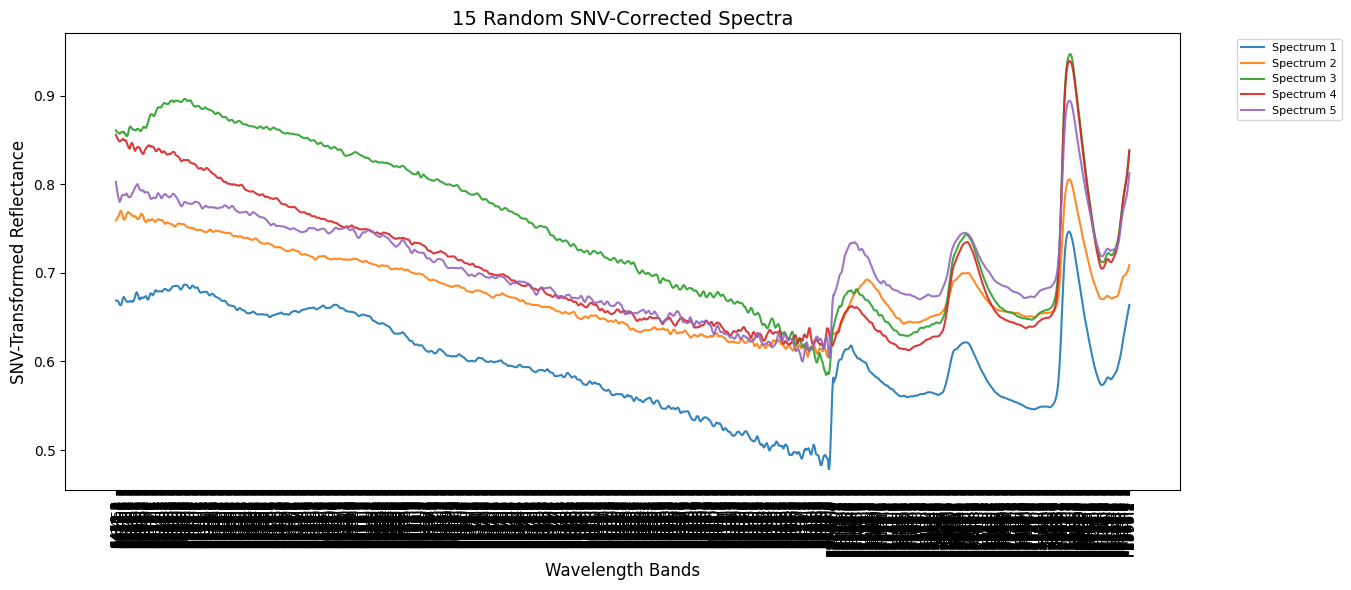

In [9]:
smooth = savgol_filter(spectra, window_length=11, polyorder=2, axis=1)
sampled = pd.DataFrame(smooth).sample(n=5, random_state=42)

# 3. Plot
plt.figure(figsize=(12, 6))

for i, (_, row) in enumerate(sampled.iterrows()):
    plt.plot(spectra_cols, row, label=f"Spectrum {i+1}", alpha=0.9)

plt.title("15 Random SNV-Corrected Spectra", fontsize=14)
plt.xlabel("Wavelength Bands", fontsize=12)
plt.ylabel("SNV-Transformed Reflectance", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=8)
plt.show()

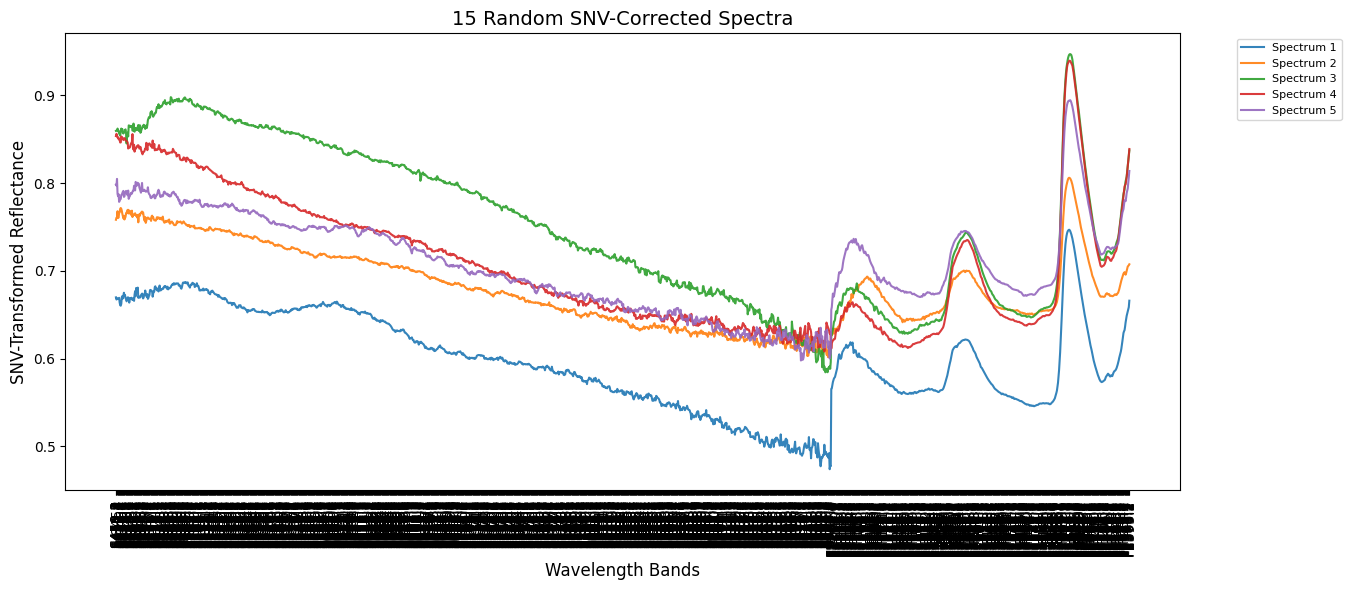

In [ ]:
# original
sampled = pd.DataFrame(spectra).sample(n=5, random_state=42)

# 3. Plot
plt.figure(figsize=(12, 6))

for i, (_, row) in enumerate(sampled.iterrows()):
    plt.plot(spectra_cols, row, label=f"Spectrum {i+1}", alpha=0.9)

plt.title("15 Random SNV-Corrected Spectra", fontsize=14)
plt.xlabel("Wavelength Bands", fontsize=12)
plt.ylabel("SNV-Transformed Reflectance", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=8)
plt.show()

## New NT III values

With this code we substitute the repeated NT3 insertions 6,8,9 and 10.

In [10]:
df = pd.read_excel("/content/CN 174-346 bis 401_with_codes.xlsx")
df = df.drop([6])
df = df.loc(axis=0)[0:24]
split_cols = df['Column1'].str.split('_', expand=True)
split_cols.columns = ['prefix', 'middle', 'depth']

# Create the new DataFrame
new_df = pd.DataFrame({
    'PlotName': 'NT_III',
    'Insertion': split_cols['middle'].apply(lambda x: f"ins{int(x):03d}"),
    'Depth_interval': split_cols['depth'].astype(int),
    'TC': df['Carbon %']
})

print(new_df)

   PlotName Insertion  Depth_interval     TC
0    NT_III    ins009               0  3.934
1    NT_III    ins009               1  3.760
2    NT_III    ins009               2  3.646
3    NT_III    ins009               3  3.032
4    NT_III    ins009               4  3.443
5    NT_III    ins009               6  5.388
7    NT_III    ins006               0  3.644
8    NT_III    ins006               1  3.545
9    NT_III    ins006               2  3.230
10   NT_III    ins006               3  3.083
11   NT_III    ins006               4  3.848
12   NT_III    ins006               6  4.345
13   NT_III    ins008               0  3.691
14   NT_III    ins008               1  3.627
15   NT_III    ins008               2  3.116
16   NT_III    ins008               3  3.076
17   NT_III    ins008               4  4.113
18   NT_III    ins008               6  3.945
19   NT_III    ins010               0  3.589
20   NT_III    ins010               1  3.408
21   NT_III    ins010               2  2.978
22   NT_II

In [11]:
df = pd.read_excel("/content/Scheibler_Pavel.xls", sheet_name=1,header=3)
split_cols = df['Proben-Bez.'].str.split('_', expand=True)
split_cols.columns = ['prefix', 'middle', 'depth']

# Create the new DataFrame
new_sic = pd.DataFrame({
    'PlotName': 'NT_III',
    'Insertion': split_cols['middle'].apply(lambda x: f"ins{int(x):03d}"),
    'Depth_interval': split_cols['depth'].astype(int),
    'SIC': df['%Canorg ']
})

print(new_sic)

   PlotName Insertion  Depth_interval       SIC
0    NT_III    ins009               6  3.803287
1    NT_III    ins009               4  1.658024
2    NT_III    ins009               3  1.625977
3    NT_III    ins009               2  1.843302
4    NT_III    ins009               1  1.624967
5    NT_III    ins009               0  1.552163
6    NT_III    ins006               6  3.629951
7    NT_III    ins006               4  2.330339
8    NT_III    ins006               3  1.620533
9    NT_III    ins006               2  1.644865
10   NT_III    ins006               1  1.713947
11   NT_III    ins006               0  1.230301
12   NT_III    ins008               6  3.766460
13   NT_III    ins008               4  2.675862
14   NT_III    ins008               3  1.806442
15   NT_III    ins008               2  1.677590
16   NT_III    ins008               1  1.652601
17   NT_III    ins008               0  1.353084
18   NT_III    ins010               6  3.442651
19   NT_III    ins010               4  1

In [12]:
data = sid_filtered_data2.copy()

In [13]:
# Set indexes
data_indexed = data.set_index(['PlotName', 'Insertion', 'Depth_interval'])
new_indexed = new_df.set_index(['PlotName', 'Insertion', 'Depth_interval'])
new_indx = new_sic.set_index(['PlotName', 'Insertion', 'Depth_interval'])

# Identify rows that will be updated (union of TC and SIC updates)
update_idx = data_indexed.index.intersection(
    new_indexed.index.union(new_indx.index)
)

# Update TC and SIC
data_indexed.update(new_indexed[['TC']])
data_indexed.update(new_indx[['SIC']])

# Recalculate SOC only for affected rows
data_indexed.loc[update_idx, 'SOC'] = (
    data_indexed.loc[update_idx, 'TC'] -
    data_indexed.loc[update_idx, 'SIC']
)

# Reset index
data2 = data_indexed.reset_index()

There are two datasets, the old one as "data" and "data2" with repeated NT3 insertions.

## Heatmap

Missing values per variable:
TC        0
SOC       0
Water    74
SIC       0
Force     0
Depth     0
dtype: int64


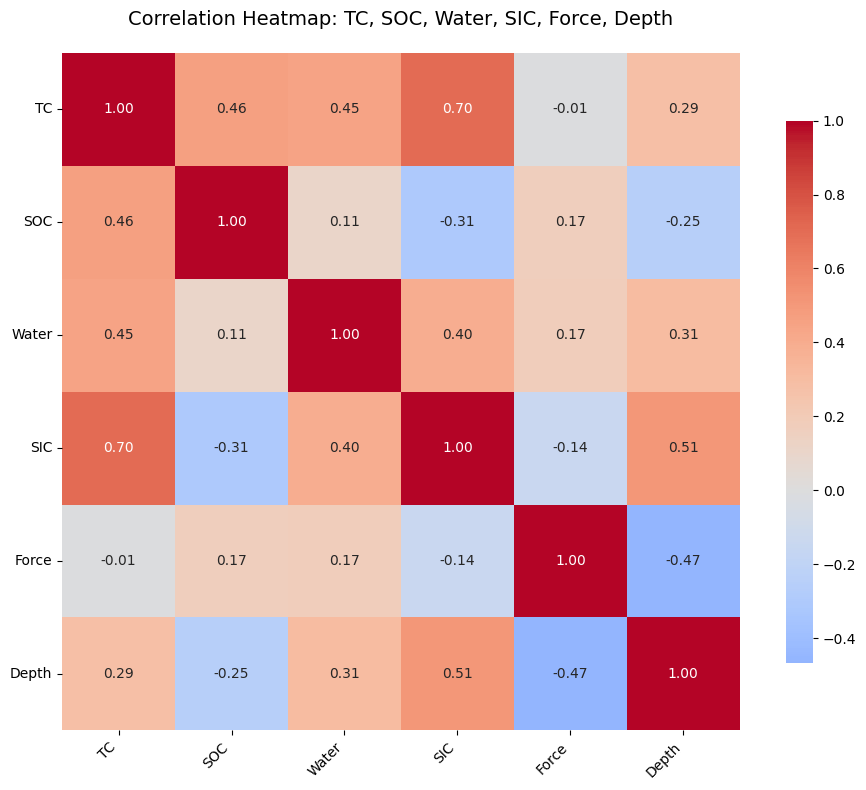


Correlation Matrix:
          TC    SOC  Water    SIC  Force  Depth
TC     1.000  0.462  0.450  0.703 -0.011  0.286
SOC    0.462  1.000  0.108 -0.306  0.165 -0.251
Water  0.450  0.108  1.000  0.396  0.174  0.312
SIC    0.703 -0.306  0.396  1.000 -0.144  0.508
Force -0.011  0.165  0.174 -0.144  1.000 -0.466
Depth  0.286 -0.251  0.312  0.508 -0.466  1.000


In [ ]:
import seaborn as sns

df = data2.copy()
df = df[df['Water'] != 0.0]
target_vars = ['TC',   'SOC',  'Water',  'SIC', 'Force', 'Depth']

# Check which variables actually exist in your dataset
existing_vars = [var for var in target_vars if var in df.columns]
missing_vars = [var for var in target_vars if var not in df.columns]

if missing_vars:
    print(f"Warning: These variables are not in your dataset: {missing_vars}")

if len(existing_vars) < 2:
    print("Error: Need at least 2 variables to create correlation matrix")
else:
    # Extract the relevant columns
    correlation_data = df[existing_vars].copy()

    # Check for missing values
    print("Missing values per variable:")
    print(correlation_data.isnull().sum())

    # Remove rows with missing values for correlation calculation
    correlation_data_clean = correlation_data.dropna()

    if len(correlation_data_clean) == 0:
        print("Error: No complete cases available for correlation")
    else:
        # Calculate correlation matrix
        corr_matrix = correlation_data_clean.corr()

        # Create the heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix,
                    annot=True,           # Show correlation coefficients
                    cmap='coolwarm',      # Color scheme
                    center=0,            # Center colormap at 0
                    square=True,         # Make cells square
                    fmt='.2f',           # Format numbers to 2 decimal places
                    cbar_kws={'shrink': 0.8})

        plt.title('Correlation Heatmap: TC, SOC, Water, SIC, Force, Depth', fontsize=14, pad=20)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

        # Print the correlation matrix as well
        print("\nCorrelation Matrix:")
        print(corr_matrix.round(3))

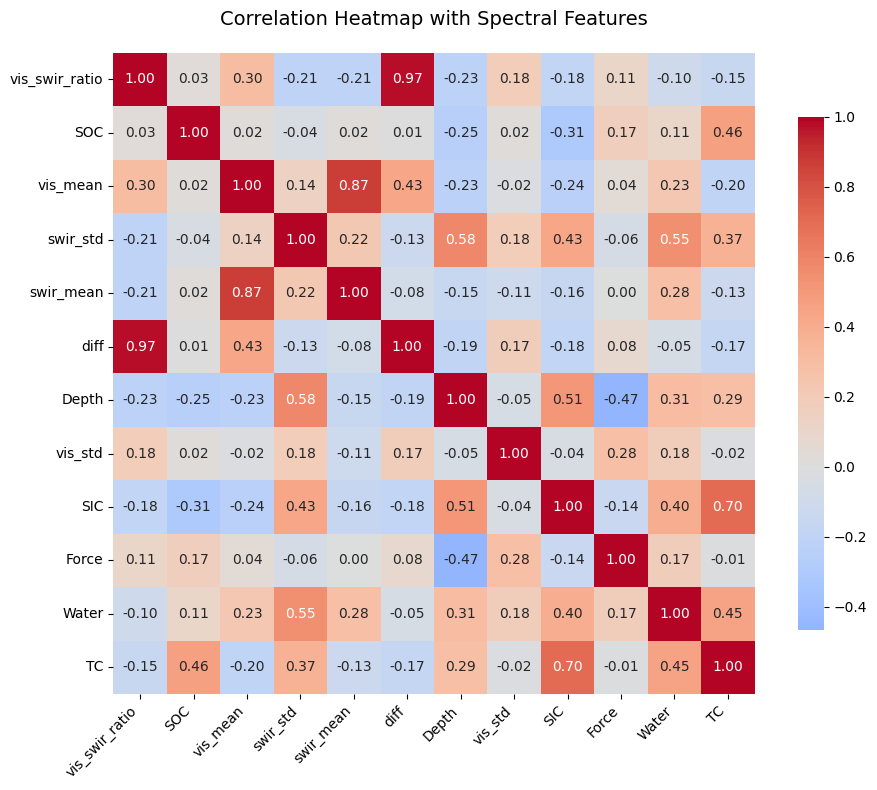


Correlation Matrix with Spectral Features:
                vis_swir_ratio    SOC  vis_mean  swir_std  swir_mean   diff  \
vis_swir_ratio           1.000  0.027     0.301    -0.206     -0.208  0.973   
SOC                      0.027  1.000     0.025    -0.042      0.022  0.009   
vis_mean                 0.301  0.025     1.000     0.136      0.865  0.432   
swir_std                -0.206 -0.042     0.136     1.000      0.222 -0.130   
swir_mean               -0.208  0.022     0.865     0.222      1.000 -0.078   
diff                     0.973  0.009     0.432    -0.130     -0.078  1.000   
Depth                   -0.225 -0.251    -0.229     0.576     -0.147 -0.190   
vis_std                  0.182  0.024    -0.017     0.183     -0.113  0.170   
SIC                     -0.180 -0.306    -0.235     0.433     -0.158 -0.184   
Force                    0.107  0.165     0.038    -0.056      0.000  0.076   
Water                   -0.101  0.108     0.227     0.548      0.281 -0.053   
TC      

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd

df = data2.copy()
df = df[df['Water'] != 0.0]

# Define spectral columns from the filtered df
vis_cols = [c for c in df.columns if re.match(r'^[S]\d', str(c))]          # Visible: 400–1000 nm
swir_cols = [c for c in df.columns if re.match(r'^[F]\d', str(c))]

target_vars = ['TC',  'SOC',  'Water',  'SIC' ,'Depth', 'Force']

# Check which target variables actually exist in your dataset
existing_target_vars = [var for var in target_vars if var in df.columns]
missing_target_vars = [var for var in target_vars if var not in df.columns]

if missing_target_vars:
    print(f"Warning: These target variables are not in your dataset: {missing_target_vars}")

# Combine all columns needed for correlation_data: existing target variables and spectral columns
all_cols_for_correlation_data = list(set(existing_target_vars + vis_cols + swir_cols))

# Filter one more time to be absolutely sure all columns exist in df before creating correlation_data
final_cols_for_correlation_data = [col for col in all_cols_for_correlation_data if col in df.columns]

if not final_cols_for_correlation_data:
    print("Error: No columns selected for correlation analysis.")
    correlation_data = pd.DataFrame() # Create an empty dataframe to prevent further errors
else:
    # Create correlation dataframe with all necessary columns
    correlation_data = df[final_cols_for_correlation_data].copy()

    # Now, calculate derived features.
    # Ensure vis_cols and swir_cols used here only refer to columns actually present in correlation_data.
    vis_cols_in_corr_data = [col for col in vis_cols if col in correlation_data.columns]
    swir_cols_in_corr_data = [col for col in swir_cols if col in correlation_data.columns]

    if vis_cols_in_corr_data:
        correlation_data['vis_mean'] = correlation_data[vis_cols_in_corr_data].mean(axis=1)
        correlation_data['vis_std'] = correlation_data[vis_cols_in_corr_data].std(axis=1)
    else:
        correlation_data['vis_mean'] = np.nan
        correlation_data['vis_std'] = np.nan
        print("Warning: No visible spectral columns available for 'vis_mean' and 'vis_std' calculation.")

    if swir_cols_in_corr_data:
        correlation_data['swir_mean'] = correlation_data[swir_cols_in_corr_data].mean(axis=1)
        correlation_data['swir_std'] = correlation_data[swir_cols_in_corr_data].std(axis=1)
    else:
        correlation_data['swir_mean'] = np.nan
        correlation_data['swir_std'] = np.nan
        print("Warning: No SWIR spectral columns available for 'swir_mean' and 'swir_std' calculation.")

    # Calculate 'diff' and 'vis_swir_ratio'
    if 'vis_mean' in correlation_data.columns and 'swir_mean' in correlation_data.columns:
        correlation_data['diff'] = correlation_data['vis_mean'] - correlation_data['swir_mean']
        # Handle potential division by zero by replacing 0 with NaN in the denominator
        correlation_data['vis_swir_ratio'] = correlation_data['vis_mean'] / correlation_data['swir_mean'].replace(0, np.nan)
    else:
        correlation_data['diff'] = np.nan
        correlation_data['vis_swir_ratio'] = np.nan
        print("Warning: Cannot calculate 'diff' and 'vis_swir_ratio' due to missing mean values.")

    # Define the final set of columns for the correlation matrix heatmap
    # This will include original target_vars that were present and the newly calculated features
    final_heatmap_cols = list(set(existing_target_vars + ['vis_mean', 'swir_mean', 'diff', 'vis_swir_ratio', 'vis_std', 'swir_std']))
    final_heatmap_cols = [col for col in final_heatmap_cols if col in correlation_data.columns]

    if len(final_heatmap_cols) < 2:
        print("Error: Need at least 2 variables (including derived features) to create correlation matrix.")
    else:
        # Remove rows with missing values for correlation calculation
        correlation_data_clean = correlation_data[final_heatmap_cols].dropna()

        if len(correlation_data_clean) == 0:
            print("Error: No complete cases available for correlation after feature engineering and dropping NaNs.")
        else:
            # Calculate correlation matrix
            corr_matrix = correlation_data_clean.corr()

            # Create the heatmap
            plt.figure(figsize=(10, 8))
            sns.heatmap(corr_matrix,
                                annot=True,           # Show correlation coefficients
                                cmap='coolwarm',      # Color scheme
                                center=0,            # Center colormap at 0
                                square=True,         # Make cells square
                                fmt='.2f',           # Format numbers to 2 decimal places
                                cbar_kws={'shrink': 0.8})

            plt.title('Correlation Heatmap with Spectral Features', fontsize=14, pad=20)
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()

            # Print the correlation matrix as well
            print("\nCorrelation Matrix with Spectral Features:")
            print(corr_matrix.round(3))


## Density by depth and plot

In [ ]:
data2['Depth'] = round(data2['Depth'], 0)

In [ ]:
new_data2

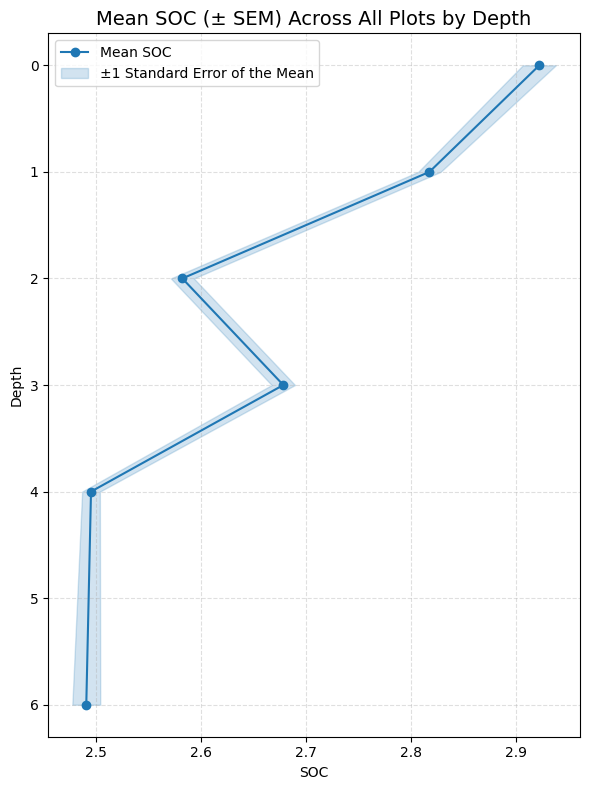

In [ ]:
import seaborn as sns

# 1) Aggregate across ALL plots and insertions → group only by Depth
grouped_all = data2.groupby('Depth_interval')['SOC'].agg(['mean', 'sem']).reset_index() #Standard Error of the Mean
grouped_all.columns = ['Depth', 'mean_SmoothSOC', 'sem_SmoothSOC']

# Optional: Sort by Depth (important if Depth isn't already sorted)
grouped_all = grouped_all.sort_values('Depth')

# 2) Create a single plot
plt.figure(figsize=(6, 8))
ax = plt.gca()

# 3) Plot mean ± SEM
ax.plot(grouped_all['mean_SmoothSOC'], grouped_all['Depth'],
        color='tab:blue', marker='o', label='Mean SOC')

ax.fill_betweenx(
    grouped_all['Depth'],
    grouped_all['mean_SmoothSOC'] - grouped_all['sem_SmoothSOC'],
    grouped_all['mean_SmoothSOC'] + grouped_all['sem_SmoothSOC'],
    color='tab:blue',
    alpha=0.2,
    label='±1 Standard Error of the Mean'
)

# 4) Invert y-axis (depth increases downward)
ax.invert_yaxis()
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlabel("SOC")
ax.set_ylabel("Depth")
ax.set_title("Mean SOC (± SEM) Across All Plots by Depth", fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

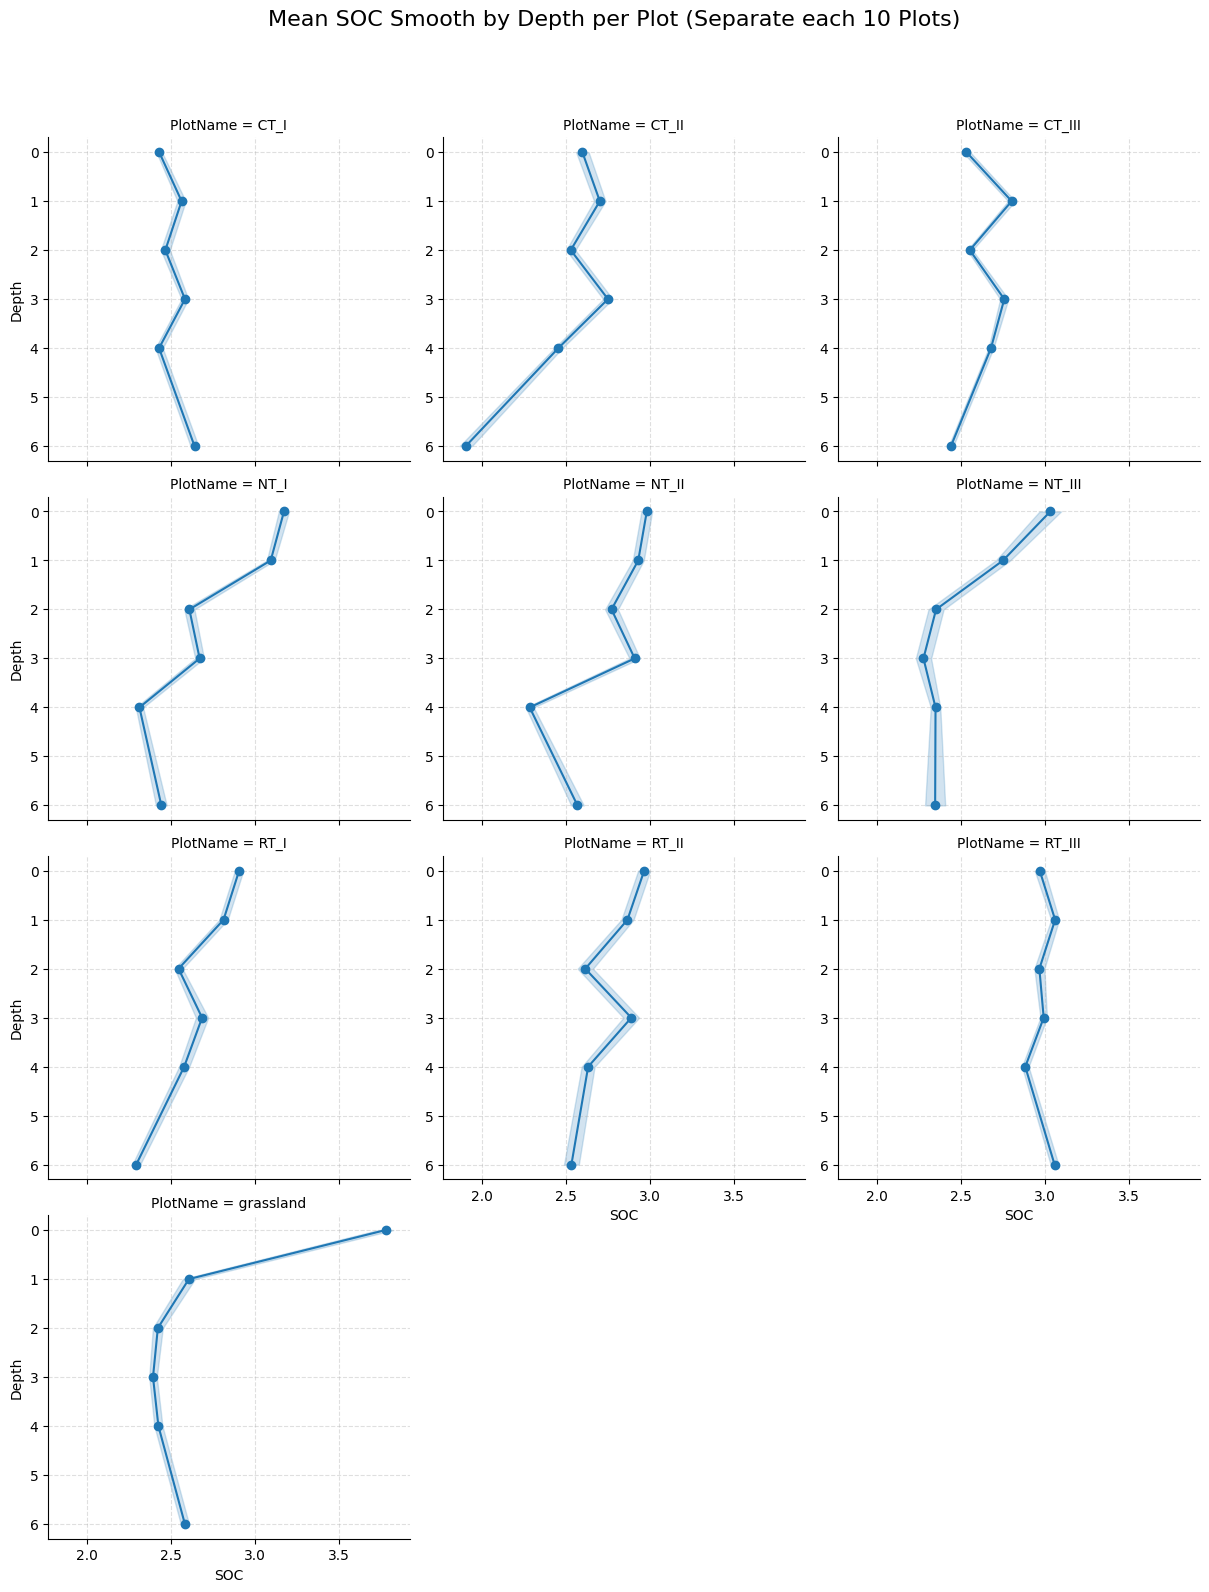

In [ ]:
import seaborn as sns

# 1) Group by PlotName & rounded Depth, then compute mean & sem of Smooth_SOC
grouped = data2.groupby(['PlotName', data2['Depth_interval']])['SOC'].agg(['mean', 'sem']).reset_index()
grouped.columns = ['PlotName', 'Depth', 'mean_SmoothSOC', 'sem_SmoothSOC']

# 2) Create FacetGrid (one subplot per PlotName)
g = sns.FacetGrid(grouped, col='PlotName', col_wrap=3, height=4, sharey=False)

# 3) Define plot function
def plot_func(data, color, **kwargs):
    ax = kwargs.get("ax", plt.gca())
    ax.plot(data['mean_SmoothSOC'], data['Depth'], color=color, marker='o')
    ax.fill_betweenx(
        data['Depth'],
        data['mean_SmoothSOC'] - data['sem_SmoothSOC'],
        data['mean_SmoothSOC'] + data['sem_SmoothSOC'],
        alpha=0.2,
        color=color
    )
    ax.invert_yaxis()  # Now this works per subplot
    ax.grid(True, linestyle='--', alpha=0.4)


# 4) Map the function to each subplot
g.map_dataframe(plot_func)

# 5) Customize labels and title
g.set_axis_labels("SOC", "Depth")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Mean SOC Smooth by Depth per Plot (Separate each 10 Plots)', fontsize=16)


plt.show()

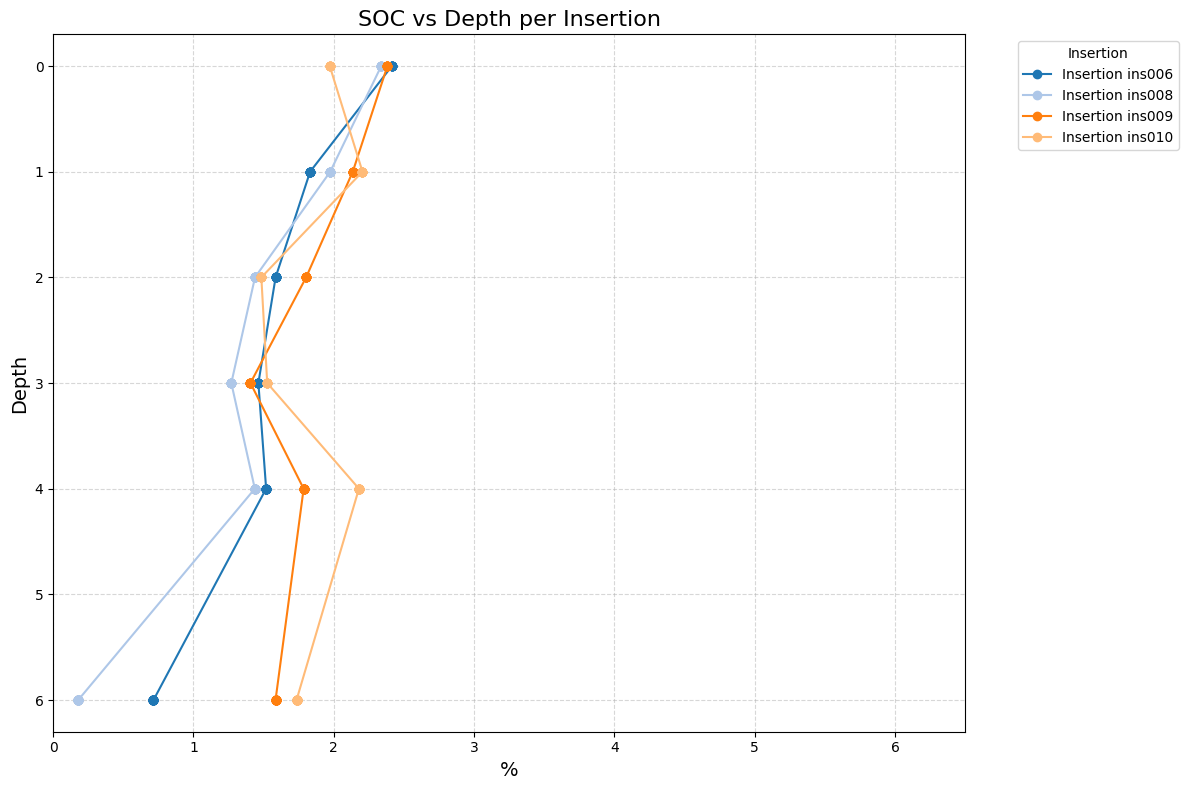

In [ ]:
subset = data2[data2['PlotName'] == "NT_III"].copy()

# Step 2: Set up the plot
plt.figure(figsize=(12, 8))

# Use a color palette for multiple insertions
insertions = ['ins006', 'ins008', 'ins009', 'ins010'] # subset['Insertion'].unique() #
colors = plt.cm.tab20.colors  # 20 distinct colors

# Step 3: Plot each insertion's SOC profile
for i, ins in enumerate(insertions):
    ins_subset = subset[subset['Insertion'] == ins]
    plt.plot(
        ins_subset['SOC'],
        ins_subset['Depth_interval'],
        label=f'Insertion {ins}',
        marker='o',
        linestyle='-',
        color=colors[i % len(colors)]
    )

# Customize the plot
plt.xlabel('%', fontsize=14)
plt.ylabel('Depth', fontsize=14)
plt.xlim(left=0., right=6.5) #right=6.5
plt.title('SOC vs Depth per Insertion', fontsize=16)
plt.gca().invert_yaxis()  # Depth increases downward
plt.legend(title='Insertion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Smoothing Target variable

This is optional, smoothing the target variable like TC, SIC, SOC or Water, to make it less squared like, and remove zigzags values present in those variables.

The GPS is necessary for this task.

In [ ]:
!pip install pyproj

In [ ]:
import pyproj
from pyproj import Transformer
# correct way to get meters from GPS
df = data2.copy()#data2
df[['Longitude', 'Latitude']] = df['GPS']\
    .str.replace(r'^POINT \(', '', regex=True)\
    .str.replace(r'\)$', '', regex=True)\
    .str.split(' ', expand=True)

# Convert to float
df['Longitude'] = df['Longitude'].astype(float)
df['Latitude'] = df['Latitude'].astype(float)

# Assume your 'df' is already loaded and cleaned as floats
# df['Latitude'], df['Longitude']

# Define the input CRS (WGS 84 standard)
crs_in = pyproj.CRS('EPSG:4326')

# Define the output CRS (UTM Zone 33N, standard for Vienna)
crs_out = pyproj.CRS('EPSG:32633')

# Create the transformer object
transformer = Transformer.from_crs(crs_in, crs_out, always_xy=True)


# Apply the transformation to your DataFrame
# 'X_m' and 'Y_m' will now contain accurate meter values within that UTM zone
df['X_m'], df['Y_m'] = transformer.transform(df['Longitude'].values, df['Latitude'].values)
df[['GPS', 'Longitude', 'Latitude', 'X_m', 'Y_m']].head()

,GPS,Longitude,Latitude,X_m,Y_m
0,POINT (16.74663415206849 48.19756120932306),16.746634,48.197561,629790.610662,5.339734e+06
1,POINT (16.74663415206849 48.19756120932306),16.746634,48.197561,629790.610662,5.339734e+06
2,POINT (16.74663415206849 48.19756120932306),16.746634,48.197561,629790.610662,5.339734e+06
3,POINT (16.74663415206849 48.19756120932306),16.746634,48.197561,629790.610662,5.339734e+06
4,POINT (16.74663415206849 48.19756120932306),16.746634,48.197561,629790.610662,5.339734e+06


#### Graph smoother

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

def graph_based_smoothing(
    df,
    x_col='X_m',
    y_col='Y_m',
    depth_col='Depth',
    target_col='TC',
    k_neighbors=10,
    n_iterations=5,
    alpha=0.6,        # smoothing strength (0 < alpha < 1)
    depth_scale=0.5
):
    """
    Graph-based Laplacian smoothing of a target column.

    Parameters
    ----------
    df : pandas.DataFrame
        Original dataframe with X, Y, Depth, and target_col
    k_neighbors : int
        Number of nearest neighbors in the graph
    n_iterations : int
        Number of smoothing iterations
    alpha : float
        Weight for original value vs neighbor average (0 = use neighbor only, 1 = keep original only)
    depth_scale : float
        Scaling factor to make depth comparable with horizontal coordinates

    Returns
    -------
    df_smoothed : copy of df with only TC_sm column added
    """

    # Copy df to avoid pollution
    df_smoothed = df.copy()

    # Prepare 3D coordinates
    coords = df[[x_col, y_col]].values.astype(float)
    depth_vals = df[depth_col].values.astype(float).reshape(-1, 1)
    coords_3d = np.hstack([coords, depth_vals * depth_scale])

    # Original target
    TC = df[target_col].values.astype(float)
    TC_sm = TC.copy()

    # Build kNN graph
    nn = NearestNeighbors(n_neighbors=min(k_neighbors + 1, len(df)))
    nn.fit(coords_3d)
    distances, indices = nn.kneighbors(coords_3d)
    # remove self (first column)
    indices = indices[:, 1:]

    # Iterate smoothing
    for it in range(n_iterations):
        neighbor_mean = np.mean(TC_sm[indices], axis=1)
        TC_sm = alpha * TC_sm + (1 - alpha) * neighbor_mean

    # Attach smoothed target
    df_smoothed['sm'] = TC_sm
    return df_smoothed


In [ ]:
df_smoothed = graph_based_smoothing(
    df,
    x_col='X_m',
    y_col='Y_m',
    depth_col='Depth',
    target_col='TC',
    k_neighbors=15, #15
    n_iterations=6, #6
    alpha=0.6, #0.6
    depth_scale=0.01 #0.01 because it is cm!!
)

print(df_smoothed[['TC', 'sm']].head())


In [ ]:
df['TC_sm'] = df_smoothed['sm']

#### Simple Empirical Bayesian Smoothing (KNN)

In [ ]:
from sklearn.neighbors import NearestNeighbors

def bayesian_smoothing(df, x_col='X_m', y_col='Y_m', depth_col='Depth',
                       target_col='TC', k_neighbors=15,
                       obs_var=1, depth_scale=0.01):
    df_bayes = df.copy()

    # Extract and scale Depth from cm → meters (X, Y assumed in meters)
    x = df[x_col].values.astype(float)
    y = df[y_col].values.astype(float)
    z = df[depth_col].values.astype(float) * depth_scale  # <-- critical fix: cm → m

    # Stack 3D coordinates (now all in meters)
    coords = np.column_stack([x, y, z])

    # Target values
    y_vals = df[target_col].values.astype(float)

    # Nearest neighbors in physically consistent 3D space
    nn = NearestNeighbors(n_neighbors=k_neighbors + 1)
    nn.fit(coords)
    _, indices = nn.kneighbors(coords)
    indices = indices[:, 1:]  # exclude self

    # Smoothing
    sm = np.zeros_like(y_vals)
    for i in range(len(y_vals)):
        neighbors = y_vals[indices[i]]
        mu_N = neighbors.mean()
        tau2 = max(np.var(neighbors, ddof=1), 1e-6)
        sigma2 = obs_var
        posterior_mean = (mu_N / tau2 + y_vals[i] / sigma2) / (1/tau2 + 1/sigma2)
        sm[i] = posterior_mean

    df_bayes['sm'] = sm
    return df_bayes

In [ ]:
df_bayes_smoothed = bayesian_smoothing(df, target_col= 'TC', k_neighbors=15, obs_var=1, depth_scale=0.01)

In [ ]:
df['TC_sm'] = df_bayes_smoothed['sm']

#### Bayessian smoothing with global mean taking into account (stronger smoothing, great influence from the global mean)

In [ ]:
from scipy.interpolate import interp1d
from sklearn.neighbors import NearestNeighbors
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

def bayesian_smoothing_with_global_prior(
    df,
    x_col='X_m',
    y_col='Y_m',
    depth_col='Depth',
    target_col='TC',
    k_neighbors=15,
    obs_var=1.0,
    local_var_prior=1.0,
    global_var_prior=0.5,
    depth_scale=0.01, # it is cm !
    global_profile=None
):
    df_bayes = df.copy()

    # --- Input validation and cleaning ---
    x = df[x_col].values.astype(float)
    y = df[y_col].values.astype(float)
    z = df[depth_col].values.astype(float) * depth_scale
    depths = df[depth_col].values.astype(float)
    y_vals = df[target_col].values.astype(float)

    # Mask out any rows where target or coords are NaN
    valid_mask = (
        np.isfinite(x) & np.isfinite(y) & np.isfinite(z) &
        np.isfinite(depths) & np.isfinite(y_vals)
    )

    if not np.any(valid_mask):
        raise ValueError("No valid data points after NaN filtering.")

    x, y, z, depths, y_vals = x[valid_mask], y[valid_mask], z[valid_mask], depths[valid_mask], y_vals[valid_mask]
    coords = np.column_stack([x, y, z])

    # --- Step 1: Global prior μ₀(d) ---
    if global_profile is None:
        # Remove duplicates in depth for LOWESS (critical!)
        unique_depths, unique_idx = np.unique(depths, return_index=True)
        unique_y = y_vals[unique_idx]

        # Fit LOWESS only if enough unique points
        if len(unique_depths) < 5:
            # Fallback: constant global mean
            mu0_global = np.full_like(depths, np.nanmean(y_vals))
        else:
            try:
                smoothed = lowess(
                    unique_y, unique_depths,
                    frac=min(0.3, max(0.1, 5.0 / len(unique_depths))),
                    it=0,  # disable robustness iterations to avoid NaNs
                    return_sorted=False
                )
                # Interpolate back to all depths
                mu0_interp = interp1d(
                    unique_depths, smoothed,
                    kind='linear',
                    fill_value="extrapolate",
                    bounds_error=False
                )
                mu0_global = mu0_interp(depths)
            except Exception:
                # Fallback if LOWESS fails
                mu0_global = np.full_like(depths, np.nanmean(y_vals))
    else:
        depth_grid, mu0_vals = global_profile
        mu0_interp = interp1d(
            depth_grid, mu0_vals,
            kind='linear',
            fill_value="extrapolate",
            bounds_error=False
        )
        mu0_global = mu0_interp(depths)

    # Ensure no NaNs in global prior
    mu0_global = np.where(np.isfinite(mu0_global), mu0_global, np.nanmean(y_vals))

    # --- Step 2: Local neighbors ---
    nn = NearestNeighbors(n_neighbors=min(k_neighbors + 1, len(coords)))
    nn.fit(coords)
    _, indices = nn.kneighbors(coords)
    indices = indices[:, 1:]  # exclude self

    # --- Step 3: Bayesian update ---
    sm = np.full(len(y_vals), np.nan)  # initialize with NaN
    global_mean = np.nanmean(y_vals)   # fallback value

    for i in range(len(y_vals)):
        neighbors = y_vals[indices[i]]
        # Filter finite neighbors
        finite_neighbors = neighbors[np.isfinite(neighbors)]

        if len(finite_neighbors) == 0:
            mu_local = global_mean
            var_local = local_var_prior
        else:
            mu_local = np.mean(finite_neighbors)
            var_local = max(np.var(finite_neighbors, ddof=1), 1e-6)

        # Use global prior (already cleaned)
        mu_g = mu0_global[i]
        if not np.isfinite(mu_g):
            mu_g = global_mean

        # Inverse-variance weighted prior
        w_global = 1.0 / global_var_prior
        w_local = 1.0 / local_var_prior
        mu_prior = (w_global * mu_g + w_local * mu_local) / (w_global + w_local)
        tau2_prior = 1.0 / (w_global + w_local)

        # Posterior mean
        if not np.isfinite(y_vals[i]):
            posterior_mean = mu_prior  # if observation is NaN, use prior
        else:
            posterior_mean = (
                (mu_prior / tau2_prior) + (y_vals[i] / obs_var)
            ) / (1.0 / tau2_prior + 1.0 / obs_var)

        sm[i] = posterior_mean if np.isfinite(posterior_mean) else global_mean

    # Reconstruct full output array (including original NaN positions)
    full_sm = np.full(len(df), np.nan)
    full_global = np.full(len(df), np.nan)
    full_sm[valid_mask] = sm
    full_global[valid_mask] = mu0_global

    df_bayes['sm'] = full_sm
    df_bayes['global_prior'] = full_global
    return df_bayes

In [ ]:
import numpy as np
from scipy.interpolate import interp1d
from sklearn.neighbors import NearestNeighbors
from statsmodels.nonparametric.smoothers_lowess import lowess

def estimate_bayesian_priors(
    df,
    x_col='X_m',
    y_col='Y_m',
    depth_col='Depth',
    target_col='TC',
    k_neighbors=15,
    depth_scale=0.01, # because it is cm!
    frac_lowess=0.2
):
    # --- 1. Clean data ---
    x = df[x_col].values.astype(float)
    y = df[y_col].values.astype(float)
    z = df[depth_col].values.astype(float) * depth_scale
    depths = df[depth_col].values.astype(float)
    y_vals = df[target_col].values.astype(float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(z) & np.isfinite(depths) & np.isfinite(y_vals)
    if not np.any(valid):
        raise ValueError("No valid data points.")

    x, y, z, depths, y_vals = x[valid], y[valid], z[valid], depths[valid], y_vals[valid]
    coords = np.column_stack([x, y, z])
    total_var = np.var(y_vals, ddof=1)

    if total_var == 0:
        total_var = 1.0  # fallback to avoid division by zero later

    # --- 2. Global prior: handle duplicates in depth ---
    # Remove duplicates by averaging target values at same depth
    unique_depths, inverse_idx, counts = np.unique(depths, return_inverse=True, return_counts=True)

    if len(unique_depths) < 3:
        # Not enough unique depths → use global mean
        mu0_global = np.full_like(y_vals, np.mean(y_vals))
        global_var_prior = total_var
    else:
        # Average y_vals at each unique depth
        y_at_unique = np.array([
            np.mean(y_vals[depths == d]) for d in unique_depths
        ])

        # Ensure no NaNs
        y_at_unique = np.where(np.isfinite(y_at_unique), y_at_unique, np.nanmean(y_vals))

        # Fit LOWESS only if we have enough points
        try:
            frac = min(0.3, max(0.1, 5.0 / len(unique_depths)))
            smoothed = lowess(
                y_at_unique, unique_depths,
                frac=frac,
                it=0,  # disable robustness to avoid NaNs
                delta=0.0,
                return_sorted=False
            )

            # Interpolate back to original depths
            mu0_interp = interp1d(
                unique_depths, smoothed,
                kind='linear',
                fill_value="extrapolate",
                bounds_error=False
            )
            mu0_global = mu0_interp(depths)

            # If interpolation fails (e.g., all NaN), fall back
            if not np.all(np.isfinite(mu0_global)):
                mu0_global = np.full_like(y_vals, np.mean(y_vals))

        except Exception as e:
            # Fallback on any error
            mu0_global = np.full_like(y_vals, np.mean(y_vals))

        # Compute global residual variance
        residuals = y_vals - mu0_global
        global_var_prior = np.var(residuals, ddof=1)
        if not np.isfinite(global_var_prior) or global_var_prior <= 0:
            global_var_prior = total_var

    # Ensure positivity
    global_var_prior = max(global_var_prior, 1e-6)

    # --- 3. Local variance ---
    nn = NearestNeighbors(n_neighbors=min(k_neighbors + 1, len(coords)))
    nn.fit(coords)
    _, indices = nn.kneighbors(coords)
    indices = indices[:, 1:]  # exclude self

    local_vars = []
    for i in range(len(y_vals)):
        neighbors = y_vals[indices[i]]
        finite_neighbors = neighbors[np.isfinite(neighbors)]
        if len(finite_neighbors) > 1:
            var = np.var(finite_neighbors, ddof=1)
            if np.isfinite(var) and var > 0:
                local_vars.append(var)

    if local_vars:
        local_var_prior = np.median(local_vars)
    else:
        local_var_prior = total_var

    local_var_prior = max(local_var_prior, 1e-6)

    # --- 4. Observation noise ---
    obs_var = 0.2 * total_var  # or estimate from replicates if available

    return {
        'obs_var': float(obs_var),
        'local_var_prior': float(local_var_prior),
        'global_var_prior': float(global_var_prior),
        'total_var': float(total_var)
    }

In [ ]:
estimate_bayesian_priors(df, target_col='SOC')

{'obs_var': 0.048937215664482614,
 'local_var_prior': 0.01772313333333332,
 'global_var_prior': 0.22170910099864655,
 'total_var': 0.24468607832241307}

We adjust those parameters with the estimates. YOu can ask any LLM (ChatGPT) what is doing for the estimation, by giving him the code. But basically, obs_var is 0.2 * total variation present in the target variable in the whole data (every insertion and every plot); that 0.2 doesnt really matter, because obs_var has no great leverage, you can even leave obs_var=1.0 .

Then, global_var_prior is computed with variance from residuals (smoothed with LOWESS algorithm minus original data).

Finally, the local variance is more complicated, but it is basically a median from thousands of local variances calculated from close neghbour points (15 here). So it goes every single sample point from the data and takes 15 neghbours then calculate the variance and add it to the pool, and so on. Then it does the median of everything and you got 0.017 or 0.02 .

\
You can increment local_var_prior parameter, then the global mean would have a higher influence on smoothing, for example try local_var_prior=1. We have no idea how much is the noise and distortion in our data, maybe the global mean is more reliable than local mean, but we dont know!!

In [ ]:
df_bayes_smoothed = bayesian_smoothing_with_global_prior(df,target_col="SOC", obs_var=0.04 ,local_var_prior=0.02, global_var_prior=0.22)

In [ ]:
df['SOC_sm'] = df_bayes_smoothed['sm']

In [ ]:
df_bayes_smoothed["sm"].isna().sum()

np.int64(0)

If you first smooth the TC and SIC separately.

In [ ]:
# if you first smooth the TC and SIC separately
df['SOC_sm'] = df['TC_sm'] - df['SIC_sm']

#### How the smoothing looks like

Blue the original one and Red the smoothed version.

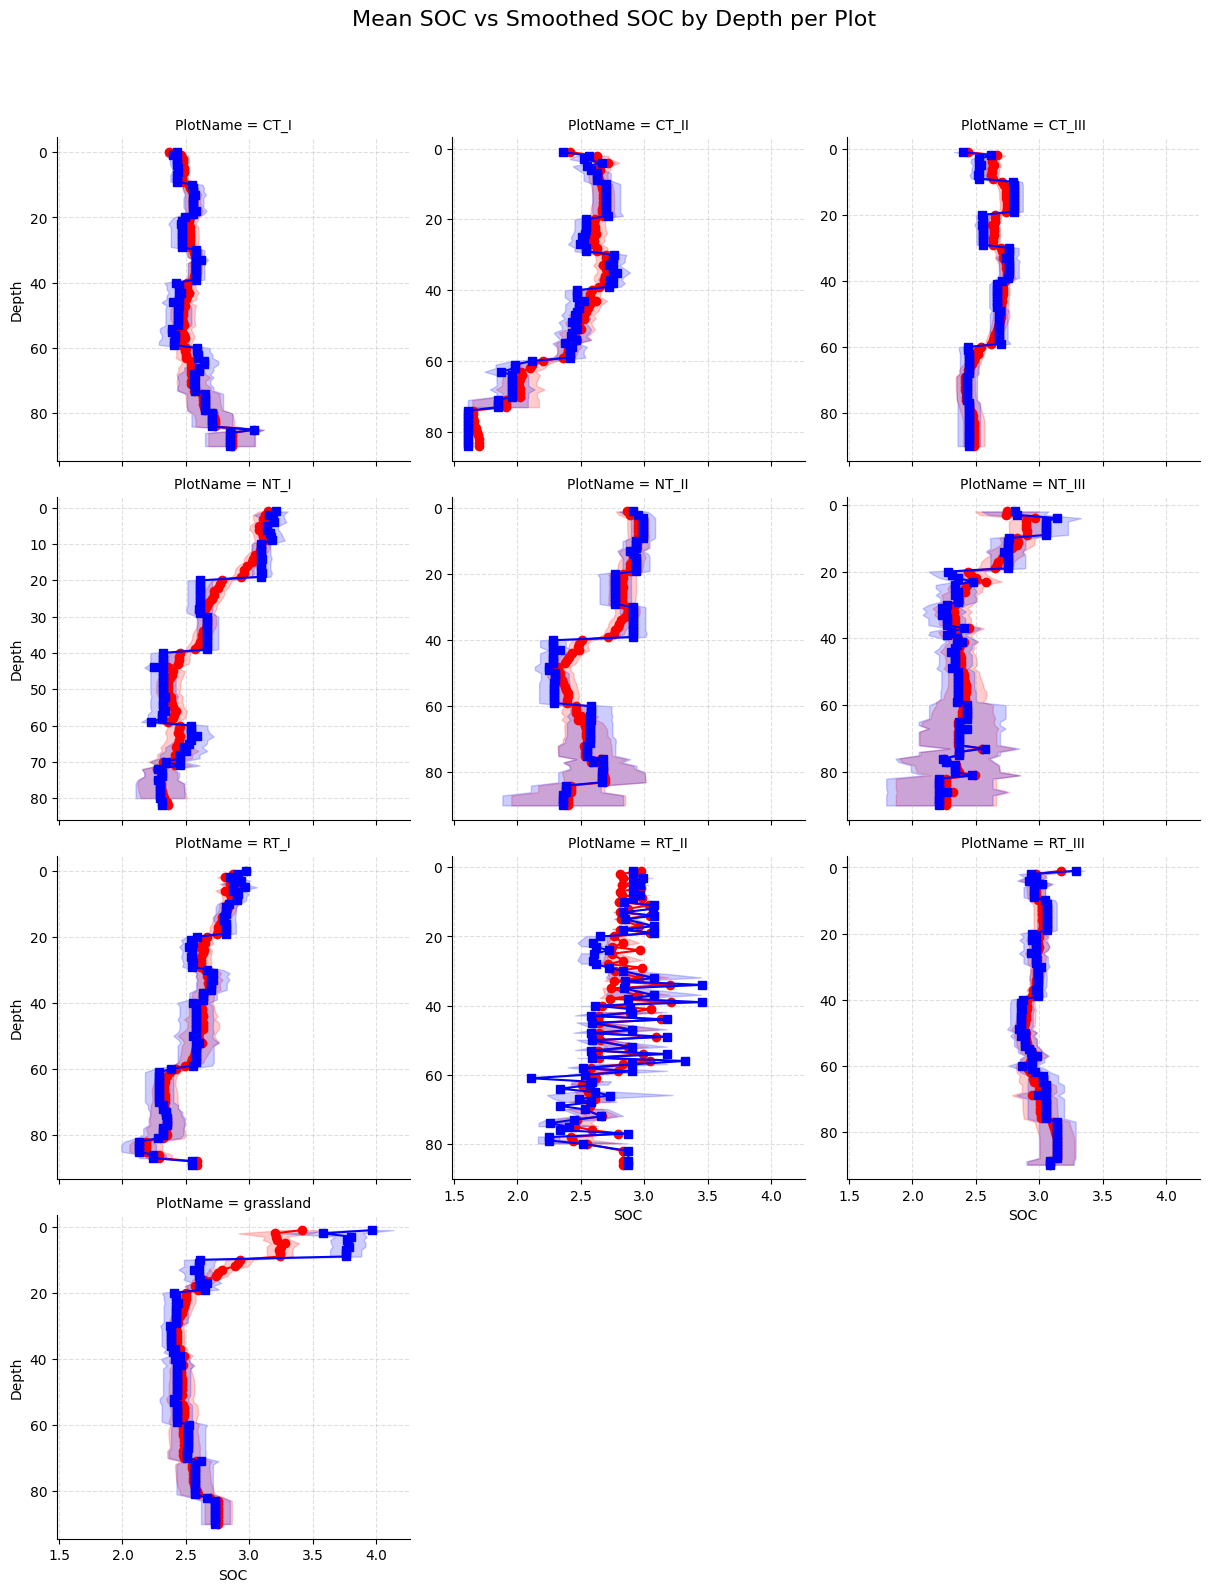

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1) Group both SOC and SOC_sm by PlotName & Depth
# First, ensure Depth is rounded if needed (assuming it's already consistent)
df_grouped = df.groupby(['PlotName', 'Depth']).agg(
    mean_SmoothSOC=('SOC_sm', 'mean'),
    sem_SmoothSOC=('SOC_sm', 'sem'),
    mean_OriginalSOC=('SOC', 'mean'),
    sem_OriginalSOC=('SOC', 'sem')
).reset_index()

# 2) Create FacetGrid
g = sns.FacetGrid(df_grouped, col='PlotName', col_wrap=3, height=4, sharey=False)

# 3) Define plot function that draws both series
def plot_func(data, **kwargs):
    ax = plt.gca()

    # Plot smoothed SOC
    ax.plot(data['mean_SmoothSOC'], data['Depth'],
            color='red', marker='o', label='Smoothed SOC')
    ax.fill_betweenx(
        data['Depth'],
        data['mean_SmoothSOC'] - data['sem_SmoothSOC'],
        data['mean_SmoothSOC'] + data['sem_SmoothSOC'],
        color='red', alpha=0.2
    )

    # Plot original SOC
    ax.plot(data['mean_OriginalSOC'], data['Depth'],
            color='blue', marker='s', label='Original SOC')
    ax.fill_betweenx(
        data['Depth'],
        data['mean_OriginalSOC'] - data['sem_OriginalSOC'],
        data['mean_OriginalSOC'] + data['sem_OriginalSOC'],
        color='blue', alpha=0.2
    )

    ax.invert_yaxis()
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend()

# 4) Map the function
g.map_dataframe(plot_func)

# 5) Labels and title
g.set_axis_labels("SOC", "Depth")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Mean SOC vs Smoothed SOC by Depth per Plot', fontsize=16)

plt.show()

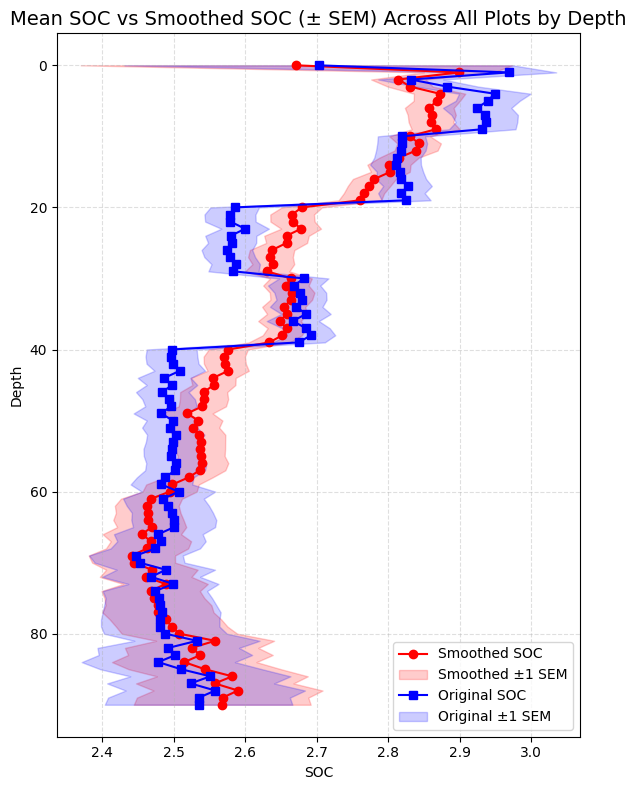

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1) Aggregate both SOC and SOC_sm across ALL plots → group only by Depth
grouped_all = df.groupby('Depth').agg(
    mean_SmoothSOC=('SOC_sm', 'mean'),
    sem_SmoothSOC=('SOC_sm', 'sem'),
    mean_OriginalSOC=('SOC', 'mean'),
    sem_OriginalSOC=('SOC', 'sem')
).reset_index()

# Sort by Depth (important for correct line plotting)
grouped_all = grouped_all.sort_values('Depth')

# 2) Create a single plot
plt.figure(figsize=(6, 8))
ax = plt.gca()

# 3) Plot Smoothed SOC (e.g., in red)
ax.plot(grouped_all['mean_SmoothSOC'], grouped_all['Depth'],
        color='red', marker='o', label='Smoothed SOC')
ax.fill_betweenx(
    grouped_all['Depth'],
    grouped_all['mean_SmoothSOC'] - grouped_all['sem_SmoothSOC'],
    grouped_all['mean_SmoothSOC'] + grouped_all['sem_SmoothSOC'],
    color='red', alpha=0.2, label='Smoothed ±1 SEM'
)

# 4) Plot Original SOC (e.g., in blue)
ax.plot(grouped_all['mean_OriginalSOC'], grouped_all['Depth'],
        color='blue', marker='s', label='Original SOC')
ax.fill_betweenx(
    grouped_all['Depth'],
    grouped_all['mean_OriginalSOC'] - grouped_all['sem_OriginalSOC'],
    grouped_all['mean_OriginalSOC'] + grouped_all['sem_OriginalSOC'],
    color='blue', alpha=0.2, label='Original ±1 SEM'
)

# 5) Final touches
ax.invert_yaxis()
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlabel("SOC")
ax.set_ylabel("Depth")
ax.set_title("Mean SOC vs Smoothed SOC (± SEM) Across All Plots by Depth", fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
df['SOC_sm'].isna().sum()
# remove nan from df
df = df.dropna(subset=['SOC_sm'])
df['SOC_sm'].isna().sum()

np.int64(0)

## PCA

In [ ]:
from sklearn.decomposition import PCA
n_components = 50
pca = PCA(n_components=n_components)
spectra_cols = [c for c in df.columns
                if re.match(r'^[SF]\d', str(c))]

X_pca = pca.fit_transform(df[spectra_cols])

Within the PCA it is possible to notice that some plots are different, we can see which PCs present the most differences!

In [ ]:
from sklearn.feature_selection import f_classif
import pandas as pd
import numpy as np

# Assume you have:
# - X_pca: PCA-transformed data (n_samples x n_pcs)
# - plot_labels: Series like ['CT_I', 'RT_III', 'Grassland', ...]
data_subset = df.copy()
# Keep only plots you care about (optional)
valid_plots = ['CT_I', 'RT_III', 'NT_III', 'grassland', 'CT_II', 'RT_I', 'RT_II', 'CT_III', 'NT_I', 'NT_II']
mask = data_subset['PlotName'].isin(valid_plots)
X_pca_clean = X_pca[mask]
plot_labels_clean = data_subset.loc[mask, 'PlotName']
# Run ANOVA F-test: higher F = more discriminative
f_scores, p_values = f_classif(X_pca_clean, plot_labels_clean)

# Create ranking
pc_ranking = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(f_scores))],
    'F_score': f_scores,
    'p_value': p_values
}).sort_values('F_score', ascending=False)

print("Top 15 PCs that differentiate plots:")
print(pc_ranking.head(15))

Top 15 PCs that differentiate plots:
      PC      F_score        p_value
7    PC8  3030.006003   0.000000e+00
2    PC3  2479.920658   0.000000e+00
4    PC5   758.187183   0.000000e+00
13  PC14   756.973632   0.000000e+00
37  PC38   570.142062   0.000000e+00
38  PC39   561.099477   0.000000e+00
40  PC41   556.390191   0.000000e+00
1    PC2   470.766650   0.000000e+00
6    PC7   260.382187   0.000000e+00
41  PC42   255.293508   0.000000e+00
36  PC37   248.020688   0.000000e+00
5    PC6   238.945331   0.000000e+00
0    PC1   235.053675   0.000000e+00
23  PC24   164.233311  7.999812e-291
26  PC27   124.039897  7.344515e-222


Here we can check those PCs in 2 dimentional plot, and see which plotnames are different from the majority. You can interact with the plot, it is intercative!

In [ ]:
import plotly.express as px

# Add plot labels to PCA df
pca_plot_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca_clean.shape[1])])
#valid_plots = ['CT_I', 'RT_III', 'NT_III', 'grassland', 'CT_II']
mask = data_subset['PlotName'].isin(valid_plots)
plot_labels_clean = data_subset.loc[mask, 'PlotName']

pca_plot_df['PlotName'] = plot_labels_clean.values
#pca_plot_df['Water'] = data[ 'Water'].values

# Plot top 2 discriminative PCs (e.g., PC5 and PC12)
fig = px.scatter(
    pca_plot_df,
    x='PC8',  # replace with top PC from ranking
    y='PC3', # replace with 2nd top
    color='PlotName',
    #size='Water',
    title='Plot Separation in Discriminative PCs',
    hover_data=['PlotName']
)
fig.show()

## EPO correction

In [39]:
# Load lab data
lab = pd.read_csv('/content/AT3_Lab.csv')
wet_raw = lab[lab['ID'].str.contains('_wet')].copy()
dry_raw = lab[lab['ID'].str.contains('_dry')].copy()

# 2. Create a 'Base_ID' by removing the suffixes
# This assumes the ID format is 'SampleName_wet' and 'SampleName_dry'
wet_raw['Base_ID'] = wet_raw['ID'].str.replace('_wet', '', regex=False)
dry_raw['Base_ID'] = dry_raw['ID'].str.replace('_dry', '', regex=False)

# 3. Find IDs that exist in BOTH groups
common_ids = set(wet_raw['Base_ID']).intersection(set(dry_raw['Base_ID']))

# 4. Filter and Sort both dataframes to match
# Using 'Base_ID' as the sorting key ensures they align row-for-row
wet = wet_raw[wet_raw['Base_ID'].isin(common_ids)].sort_values('Base_ID')
dry = dry_raw[dry_raw['Base_ID'].isin(common_ids)].sort_values('Base_ID')

# 5. Drop the helper column before proceeding to EPO
wet = wet.drop(columns=['Base_ID'])
dry = dry.drop(columns=['Base_ID'])

In [40]:
wet.shape

(101, 1914)

In [41]:
spectra_cols = [c for c in lab.columns if re.match(r'^[SF]\d', str(c))]
wet = wet[spectra_cols]
dry = dry[spectra_cols]
dry

,S449.9,S450.3,S450.7,S451.0,S451.4,S451.8,S452.2,S452.5,S452.9,S453.3,...,F2348.8,F2353.7,F2358.5,F2363.4,F2368.3,F2373.3,F2378.2,F2383.2,F2388.2,F2393.2
95,0.421617,0.421375,0.420936,0.421881,0.422006,0.422219,0.423587,0.424138,0.424109,0.422922,...,0.361833,0.361384,0.359881,0.358315,0.357193,0.358104,0.358884,0.359120,0.359497,0.358939
96,0.416049,0.415089,0.414191,0.413407,0.414086,0.414083,0.414473,0.415750,0.414563,0.415600,...,0.345162,0.345048,0.344505,0.343430,0.342128,0.343139,0.344274,0.344379,0.344144,0.344351
99,0.438233,0.436844,0.436833,0.435948,0.436999,0.436900,0.435959,0.435751,0.435644,0.433638,...,0.435445,0.435825,0.434862,0.433592,0.432615,0.434127,0.435345,0.436419,0.438347,0.439029
94,0.401703,0.401087,0.399088,0.399563,0.399613,0.399197,0.398676,0.398973,0.397474,0.397352,...,0.325078,0.324464,0.323388,0.322060,0.320831,0.320965,0.320489,0.320333,0.321045,0.321345
97,0.459660,0.460301,0.459893,0.460547,0.459280,0.460438,0.458833,0.459683,0.457265,0.457493,...,0.456151,0.455957,0.454215,0.452440,0.451385,0.452270,0.452296,0.452465,0.453745,0.453794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,0.476843,0.475279,0.476968,0.476877,0.477789,0.477272,0.478026,0.477966,0.476434,0.475872,...,0.334412,0.333600,0.332902,0.331547,0.329834,0.330593,0.331348,0.331074,0.330535,0.330002
245,0.450672,0.451151,0.452042,0.452557,0.451545,0.451157,0.451149,0.450339,0.449863,0.449926,...,0.261377,0.260616,0.259240,0.257372,0.255416,0.255952,0.256674,0.256606,0.256525,0.256283
248,0.472967,0.471984,0.473123,0.473318,0.472088,0.470260,0.469680,0.469092,0.468977,0.468449,...,0.285439,0.284611,0.283662,0.282272,0.280904,0.281420,0.281059,0.280572,0.280935,0.280845
243,0.438537,0.437545,0.437443,0.436986,0.436379,0.436308,0.436329,0.435307,0.435938,0.434828,...,0.260865,0.260175,0.258483,0.256734,0.255574,0.256003,0.255485,0.254639,0.254273,0.253950


In [42]:
wet = np.array(wet)
dry = np.array(dry)
wet[0,:]

array([0.8854974 , 0.88444149, 0.88036698, ..., 0.84389032, 0.85064601,
       0.85700095])

SGolay smoothing

Optimal Window Size: 11


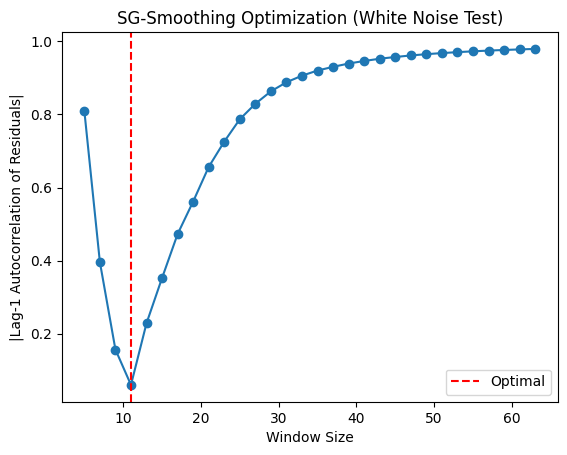

In [17]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

def calculate_lag1_autocorr(series):
    """Calculates the correlation of a signal with its own 1-step lag."""
    if len(series) < 2: return 0
    return np.corrcoef(series[:-1], series[1:])[0, 1]

def optimize_savgol(spectra, window_range=range(5, 51, 2), polyorder=2):
    """Finds the window size that minimizes residual Lag-1 autocorrelation."""
    results = []

    for w in window_range:
        # 1. Apply filter
        smoothed = savgol_filter(spectra, window_length=w, polyorder=polyorder)

        # 2. Calculate residuals (the noise removed)
        residuals = spectra - smoothed

        # 3. Measure autocorrelation of residuals
        # We want this to be near 0 (white noise)
        ac1 = calculate_lag1_autocorr(residuals)
        results.append((w, abs(ac1)))

    # Best window size has AC1 closest to 0
    best_w = min(results, key=lambda x: x[1])[0]
    return best_w, results

# --- Example Usage ---
# Assuming 'X' is a single spectrum array
best_window, all_scores = optimize_savgol(wet[0,:], range(5, 65, 2))

print(f"Optimal Window Size: {best_window}")

# Visualization
windows, scores = zip(*all_scores)
plt.plot(windows, scores, marker='o')
plt.axvline(best_window, color='r', linestyle='--', label='Optimal')
plt.xlabel('Window Size')
plt.ylabel('|Lag-1 Autocorrelation of Residuals|')
plt.title('SG-Smoothing Optimization (White Noise Test)')
plt.legend()
plt.show()


In [43]:
# Again the window is 11
wet = savgol_filter(wet, window_length=11, polyorder=2, axis=1)
dry = savgol_filter(dry, window_length=11, polyorder=2, axis=1)

Calculation of the EPO matrix

In [45]:
from scipy.linalg import svd

X0 = np.array(wet)
X1 = np.array(dry)
D = X0 - X1 # doesn't matter wet -dry or dry-wet

def epo(D, n_components=2): # we do not know how much components are needed or enough
    dtd = np.dot(D.T, D)
    S, V, d = svd(dtd)
    Q = S[:, :n_components]
    I = np.eye(D.shape[1])
    P = I - np.dot(Q, Q.T)
    return P



Let's calculate the Wilks lambda (trace ratio). We need to check where it reaches 1.0 and stays stable.

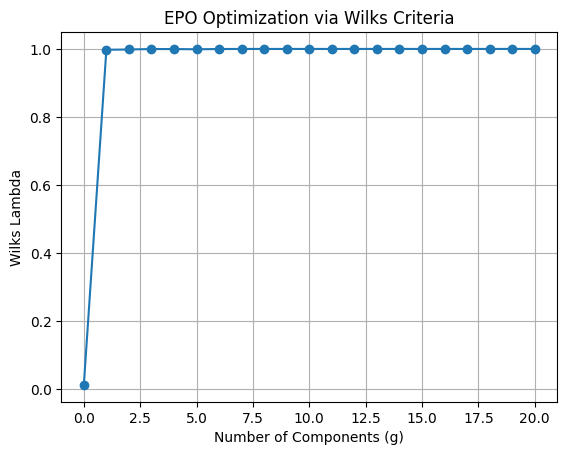

In [20]:
def calc_lambda(Z0, Z1):
    """
    Calculates Wilks' Lambda (Trace Ratio) for spectral overlap.
    """
    mu0 = Z0.mean(axis=0)
    mu1 = Z1.mean(axis=0)
    delta = mu0 - mu1

    # Between-class "variance" (trace of B)
    trace_B = np.sum(delta**2)  # because B = delta^T delta → trace = ||delta||^2

    # Within-class variance
    trace_W = np.sum(np.var(Z0, axis=0, ddof=1)) + np.sum(np.var(Z1, axis=0, ddof=1))

    # Wilks-like trace ratio (smaller = better)
    return trace_W / (trace_W + trace_B)

# --- Main Execution ---
nc = 20
wilks = np.zeros(nc + 1)

# Ensure data are numpy arrays (n_samples x n_wavelengths)
X0 = np.array(wet)
X1 = np.array(dry)
D = X0 - X1

# 1. No transformation (g = 0)
wilks[0] = calc_lambda(X0, X1)

# 2. Iterate through components
for i in range(1, nc + 1):
    P = epo(D, i)
    Z0 = np.dot(X0, P)
    Z1 = np.dot(X1, P)
    wilks[i] = calc_lambda(Z0, Z1)

# Result Visualization
import matplotlib.pyplot as plt

plt.plot(range(nc + 1), wilks, marker='o')
plt.xlabel('Number of Components (g)')
plt.ylabel('Wilks Lambda')
plt.title('EPO Optimization via Wilks Criteria')
plt.grid(True)
plt.show()

In [21]:
wilks # the first value is original data, then epo with 1 component, then epo with 2 components and so on

array([0.01320748, 0.99746554, 0.99836643, 0.99970855, 0.9995987 ,
       0.99898275, 0.99971172, 0.99993244, 0.99995965, 0.99996169,
       0.99998832, 0.99999254, 0.99999422, 0.99999564, 0.99999539,
       0.99999579, 0.99999622, 0.99999652, 0.99999925, 0.99999931,
       1.        ])

In [61]:
# One component is already enough, but it is possible to try with more, although there is a danger in loosing the other signal
epo_matrix = epo(D, n_components=1)

Correction

In [62]:
spectra_cols = [c for c in data2.columns
                if re.match(r'^[SF]\d', str(c))]

spectral_data = data2[spectra_cols].values
corrected_spectral_data = np.dot(spectral_data, epo_matrix)

# Create a new dataframe with corrected spectra
data5 = data2.copy()
data5[spectra_cols] = corrected_spectral_data

How it looks like after EPO correction

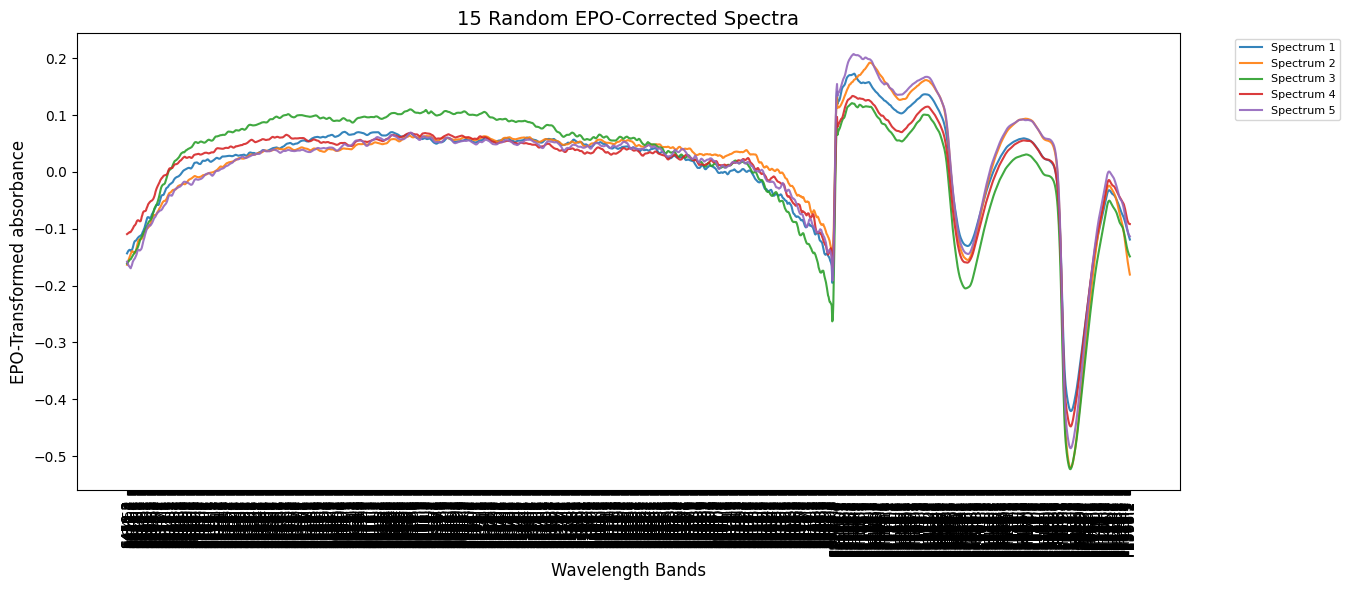

In [63]:
sampled = data5[spectra_cols].sample(n=5, random_state=42)

# 3. Plot
plt.figure(figsize=(12, 6))

for i, (_, row) in enumerate(sampled.iterrows()):
    plt.plot(spectra_cols, row, label=f"Spectrum {i+1}", alpha=0.9)

plt.title("15 Random EPO-Corrected Spectra", fontsize=14)
plt.xlabel("Wavelength Bands", fontsize=12)
plt.ylabel("EPO-Transformed absorbance", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=8)
plt.show()

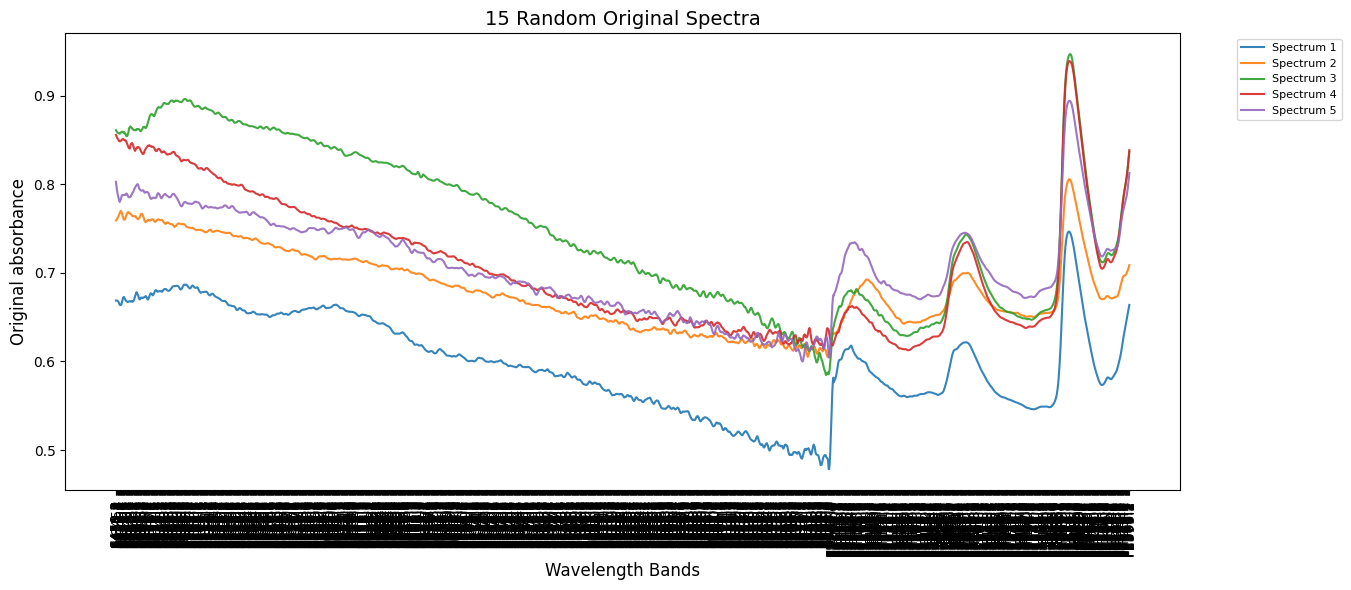

In [ ]:
sampled = df[spectra_cols].sample(n=5, random_state=42)

# 3. Plot
plt.figure(figsize=(12, 6))

for i, (_, row) in enumerate(sampled.iterrows()):
    plt.plot(spectra_cols, row, label=f"Spectrum {i+1}", alpha=0.9)

plt.title("15 Random Original Spectra", fontsize=14)
plt.xlabel("Wavelength Bands", fontsize=12)
plt.ylabel("Original absorbance", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=8)
plt.show()

Water spectra, how much is changed?

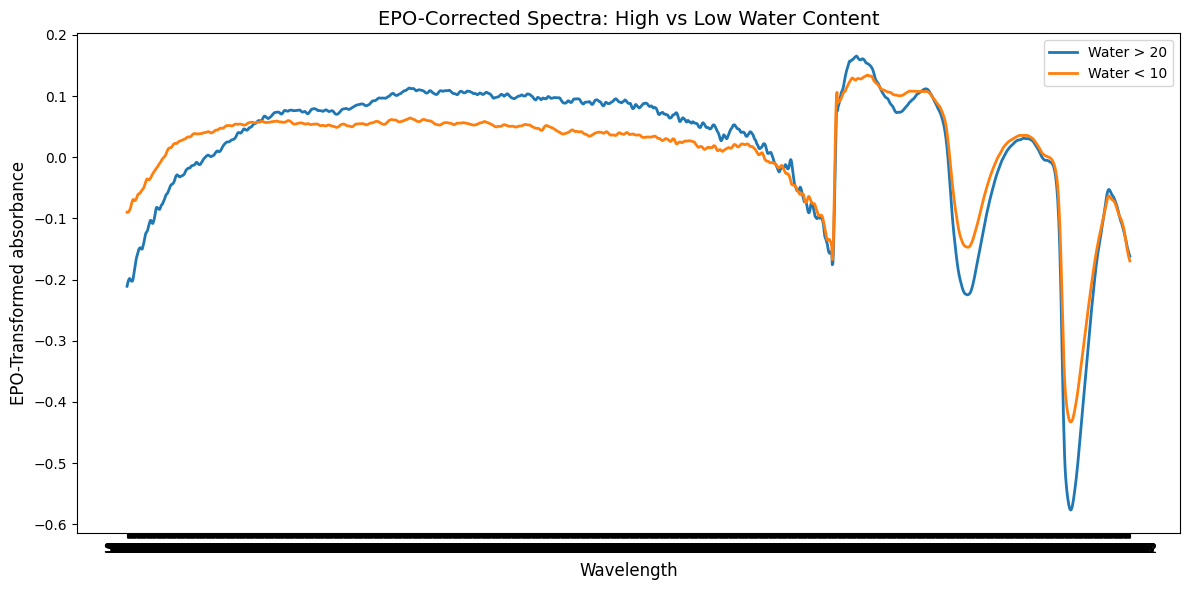

In [ ]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is called `data5` and has a column named 'Water'
high_water = data5[data5['Water'] > 20]
low_water = data5[data5['Water'] < 6]

# Pick one random sample from each (you can change random_state or use .iloc[0] for first)
sample_high = high_water[spectra_cols].sample(n=1, random_state=42).iloc[0]
sample_low = low_water[spectra_cols].sample(n=1, random_state=123).iloc[0]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(spectra_cols, sample_high, label='Water > 20', linewidth=2)
plt.plot(spectra_cols, sample_low, label='Water < 10', linewidth=2)

plt.title("EPO-Corrected Spectra: High vs Low Water Content", fontsize=14)
plt.xlabel("Wavelength", fontsize=12)
plt.ylabel("EPO-Transformed absorbance", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

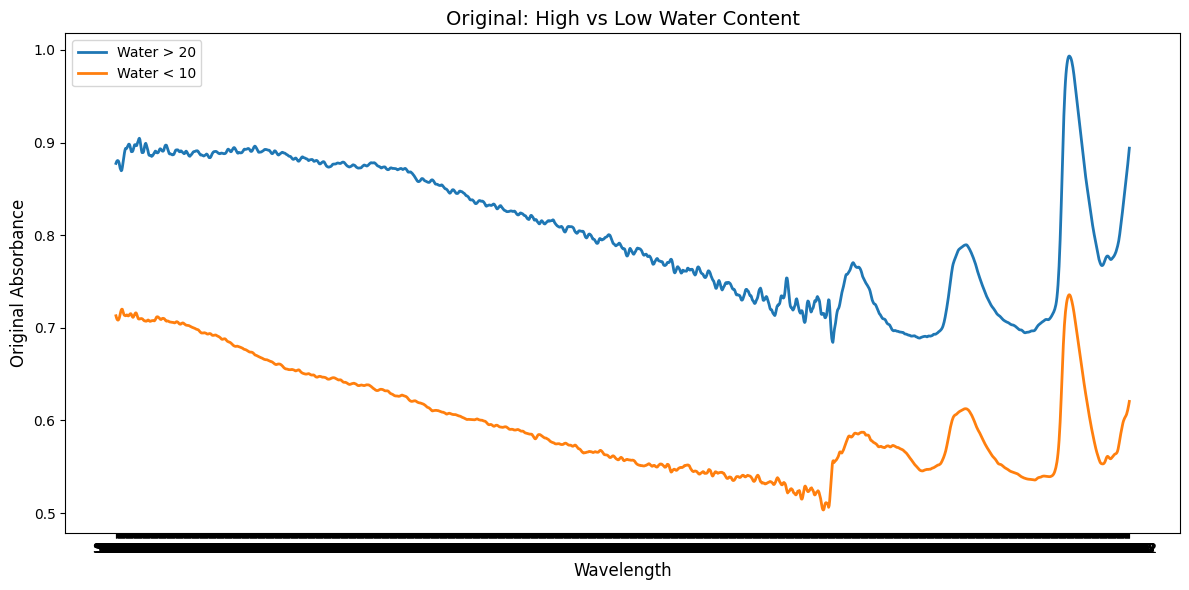

In [ ]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is called df and has a column named 'Water'
high_water = df[df['Water'] > 20]
low_water = df[df['Water'] < 6]

# Pick one random sample from each (you can change random_state or use .iloc[0] for first)
sample_high = high_water[spectra_cols].sample(n=1, random_state=42).iloc[0]
sample_low = low_water[spectra_cols].sample(n=1, random_state=123).iloc[0]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(spectra_cols, sample_high, label='Water > 20', linewidth=2)
plt.plot(spectra_cols, sample_low, label='Water < 10', linewidth=2)

plt.title("Original: High vs Low Water Content", fontsize=14)
plt.xlabel("Wavelength", fontsize=12)
plt.ylabel("Original Absorbance", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## Train

In [59]:
train, test = train_test_split(data5, test_size=0.8, random_state=23 ) #, shuffle=False

In [ ]:
# optional transformation, actually desactivated in the code
def detrend_spectra_poly(X, order=1, x=None):
    """
    Remove polynomial baseline drift from raw spectra.

    Parameters
    ----------
    X : np.ndarray
        2D array of shape (n_samples, n_wavelengths) with raw absorbance spectra.
    order : int, optional (default=1)
        Degree of the polynomial to fit and remove:
        - 0: removes constant (mean)
        - 1: removes linear trend
        - 2: removes quadratic trend, etc.
    x : np.ndarray, optional
        1D array of shape (n_wavelengths,) representing the x-axis (e.g., wavelengths).
        If None, defaults to np.arange(n_wavelengths).

    Returns
    -------
    X_detrended : np.ndarray
        Detrended spectra, same shape as X.
    """
    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError("X must be a 2D array (n_samples, n_wavelengths).")

    n_samples, n_wavelengths = X.shape
    if x is None:
        x = np.arange(n_wavelengths)
    else:
        x = np.asarray(x)
        if x.shape != (n_wavelengths,):
            raise ValueError("x must be 1D with length equal to number of wavelengths.")

    X_detrended = np.empty_like(X)

    for i, spectrum in enumerate(X):
        # Fit polynomial of given order
        coeffs = np.polyfit(x, spectrum, deg=order)
        # Evaluate polynomial baseline
        baseline = np.polyval(coeffs, x)
        # Remove baseline
        X_detrended[i] = spectrum - baseline

    return X_detrended

In [60]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import KernelPCA


from sklearn.utils import shuffle
train = shuffle(train, random_state=12)
target = 'SOC' #
y_train = train[target].round(2) #train[target] #
y_test = test[target].round(2) #

#spectra_cols = [c for c in train.columns if re.match(r'^[F]\d', str(c))]
spectra_cols = [c for c in train.columns
                if re.match(r'^[S]\d', str(c))]

vis_cols = [c for c in train.columns if re.match(r'^[S]\d', str(c))]          # Visible: 400–1000 nm
swir_cols = [c for c in train.columns if re.match(r'^[F]\d', str(c))]



M = pd.DataFrame()
#M["diff"] = train[vis_cols].mean(axis=1) - train[swir_cols].mean(axis=1)
M["vis_swir_ratio"] = train[vis_cols].mean(axis=1) / (train[swir_cols].mean(axis=1))
#M["vis_mean"] = train[vis_cols].mean(axis=1)
#M["swir_mean"] = train[swir_cols].mean(axis=1)
#M["vis_swir_ratio"] = M["vis_mean"] / (M["swir_mean"] + 1e-6)
#M["vis_std"] = train[vis_cols].std(axis=1)
M["swir_std"] = train[swir_cols].std(axis=1)




N = pd.DataFrame()
#N["diff"] = test[vis_cols].mean(axis=1) - test[swir_cols].mean(axis=1)
N["vis_swir_ratio"] = test[vis_cols].mean(axis=1) / (test[swir_cols].mean(axis=1))
#N["vis_mean"] = test[vis_cols].mean(axis=1)
#N["swir_mean"] = test[swir_cols].mean(axis=1)
#N["vis_swir_ratio"] = N["vis_mean"] / (N["swir_mean"] + 1e-6)
#N["vis_std"] = test[vis_cols].std(axis=1)
N["swir_std"] = test[swir_cols].std(axis=1)

train_features = train[spectra_cols]
test_features = test[spectra_cols]

'''
# deriv
x = np.array([float(col[1:]) for col in spectra_cols])

train_features[spectra_cols] = train_features[spectra_cols].apply(lambda row: np.gradient(row.values, x),
    axis=1,
    result_type='expand')

test_features[spectra_cols] = test_features[spectra_cols].apply(lambda row: np.gradient(row.values, x),
    axis=1,
    result_type='expand')


'''
pca = PCA(n_components=50, random_state=1)
pca.fit(train_features)
train_features1 = pca.transform(train_features)
test_features1 = pca.transform(test_features)

train_features = pd.DataFrame(train_features1)
test_features = pd.DataFrame(test_features1)

train_features = pd.concat([train_features.reset_index(drop=True),
                            M.reset_index(drop=True)], #
                            #train[['Depth']].reset_index(drop=True)],
                            #train_features[[  'spectrum_mean']].reset_index(drop=True)],, 'Depth_interval''Depth',
                            axis=1)
test_features = pd.concat([test_features.reset_index(drop=True),
                           N.reset_index(drop=True)], #
                           #test[['Depth']].reset_index(drop=True)],
                           #test_features[[  'spectrum_mean']].reset_index(drop=True)],, 'Depth_interval''Depth',
                          axis=1)

def snv_detrend(df, cols, order=1):
    # SNV
    df_snv = df[cols].apply(lambda x: (x - x.mean()) / (x.std() + 1e-8), axis=1)
    # Detrend
    return df_snv # detrend_spectra_poly(df_snv, order=order) #

swir_train = snv_detrend(train, swir_cols, order=1)
swir_test  = snv_detrend(test,  swir_cols, order=1)
swir_train = pd.DataFrame(swir_train, columns=swir_cols, index=train.index)
swir_test  = pd.DataFrame(swir_test,  columns=swir_cols, index=test.index)
#x = np.array([float(col[1:]) for col in swir_cols])
#swir_train = swir_train.apply(lambda row: np.gradient(row.values, x), axis=1, result_type='expand')
#swir_test = swir_test.apply(lambda row: np.gradient(row.values,x), axis=1, result_type='expand')

pca = PCA(n_components=50, random_state=1)
pca.fit(swir_train)
swir_train1 = pca.transform(swir_train)
swir_train1 = pd.DataFrame(swir_train1)
swir_train1.columns = swir_train1.columns + 50


swir_test1 = pca.transform(swir_test)
swir_test1 = pd.DataFrame(swir_test1)
swir_test1.columns = swir_test1.columns + 50

train_features = pd.concat([train_features.reset_index(drop=True), swir_train1.reset_index(drop=True)], axis=1)
test_features = pd.concat([test_features.reset_index(drop=True), swir_test1.reset_index(drop=True)], axis=1)

params = {
    'objective': 'regression',  # Change to 'binary' or 'multiclass' for classification
    'metric': 'rmse',  # Root Mean Squared Error
    'boosting_type': 'gbdt',  # Gradient Boosting Decision Trees
    'learning_rate': 0.01,
    'max_depth': -1,
    'n_estimators': 500,
    'verbose': 1,
    'device': 'cpu',  # Use GPU if available, switch to 'cpu' if not
    'random_state': 1
}


LGB = lgb.LGBMRegressor(**params)
LGB.fit(train_features, y_train) #, sample_weight=t_w, sample_weight=train_weights1

y_pred = LGB.predict(test_features)

#pls = PLSRegression(n_components=10)  # adjust n_components as needed
#pls.fit(train_features, y_train)
#y_pred = pls.predict(test_features).flatten()

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE
mae = mean_absolute_error(y_test, y_pred)  # MAE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE
r2 = r2_score(y_test, y_pred)  # R² Score
std_test = np.std(y_test, ddof=1)
rpd = std_test / rmse

# Print results
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"RPD: {rpd:.4f}")
print(f"R² Score: {r2:.4f}")

results = test.copy()
results['Predicted'] = y_pred

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004148 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26010
[LightGBM] [Info] Number of data points in the train set: 1953, number of used features: 102
[LightGBM] [Info] Start training from score 2.625320
RMSE: 0.4467
MAE: 0.3378
MAPE: 17.36%
RPD: 1.1095
R² Score: 0.1875


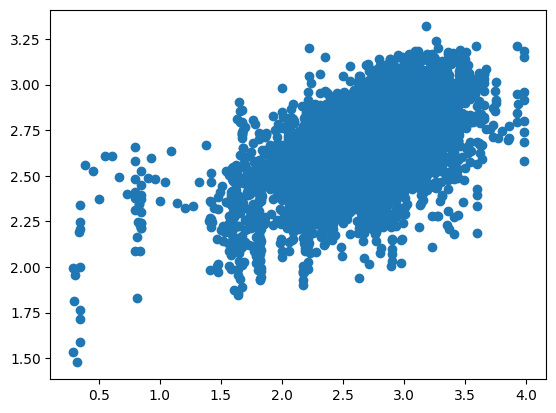

In [ ]:
plt.scatter(y_test, y_pred)

#### Feature importance

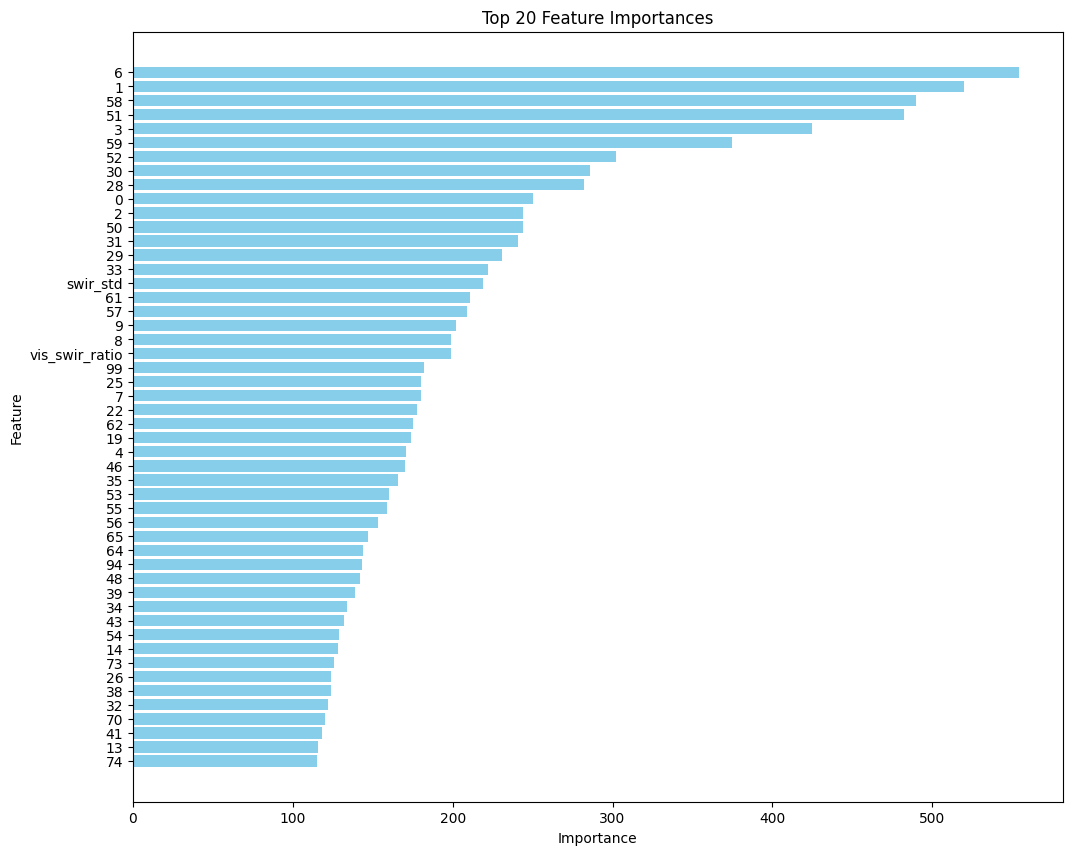

In [ ]:
spectral_cols = [c for c in df.columns
                if re.match(r'^[S]\d', str(c))]
wavebands = [float(col[1:]) for col in spectral_cols]
# Calculate feature importances
importances = LGB.feature_importances_

# Create a DataFrame for better visualization
# Use the actual column names from X_features after encoding
feature_importance_df = pd.DataFrame({
    'Feature': train_features.columns,
    'Importance': importances
})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Select the top 20 important features
top_20_features = feature_importance_df.head(50)

# Plotting the top 20 feature importances
plt.figure(figsize=(12, 10))
# Use numerical indices for y-axis and set labels explicitly
plt.barh(y=range(len(top_20_features)), width=top_20_features['Importance'], color='skyblue')
plt.yticks(range(len(top_20_features)), top_20_features['Feature'])
plt.gca().invert_yaxis()  # Invert y-axis to have the highest importance feature at the top
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Model with sinthetic data

In [ ]:
def generate_with_logging(train_features, spectral_cols, n_synthetic=800, seed=42):
    """
    Generate synthetic data while logging all extension decisions
    """
    np.random.seed(seed)
    alpha=1
    pca = PCA(n_components=50)
    X_pca = pca.fit_transform(train_features[spectral_cols])

    synthetic_samples = []
    extension_log = []

    for sample_id in range(n_synthetic):
        orig_idx = np.random.choice(len(train_features))
        orig_pca = X_pca[orig_idx].copy()
        enhanced_pca = orig_pca.copy()


        for dir_idx in range(0, 50):  #selected_pc_indices PC1-PC50
            comp_min = np.min(X_pca[:, dir_idx])
            comp_max = np.max(X_pca[:, dir_idx])
            comp_range = comp_max - comp_min

            random_val = np.random.random()
            if random_val < 0.5:
                direction = "max"
                extension = comp_max + np.random.uniform(0.2*alpha, 0.4*alpha) * comp_range
            else:
                direction = "min"
                extension = comp_min - np.random.uniform(0.1*alpha, 0.5*alpha) * comp_range

            enhanced_pca[dir_idx] = extension

            # Log this decision
            extension_log.append({
                'sample_id': sample_id,
                'component': dir_idx + 1,
                'comp_min': comp_min,
                'comp_max': comp_max,
                'comp_range': comp_range,
                'direction': direction,
                'random_val': random_val,
                'extension_val': extension
            })

        # Transform back to spectral space
        enhanced_spectral = pca.inverse_transform(enhanced_pca.reshape(1, -1))
        enhanced_spectral = np.clip(enhanced_spectral, 0, 0.6)

        new_sample = train_features.iloc[orig_idx].copy()
        for j, col in enumerate(spectral_cols):
            new_sample[col] = enhanced_spectral[0, j]
        synthetic_samples.append(new_sample)

    return pd.DataFrame(synthetic_samples), pd.DataFrame(extension_log)

The train data is used to generate the synthetic data only for pca transformation, nothing else. It improves a bit the results!

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import KernelPCA


from sklearn.utils import shuffle
train = shuffle(train, random_state=12)
target = 'SOC_sm' #
y_train = train[target].round(2) #train[target] #
y_test = test[target].round(2) #

#spectra_cols = [c for c in train.columns if re.match(r'^[F]\d', str(c))]
spectra_cols = [c for c in train.columns
                if re.match(r'^[S]\d', str(c))]

vis_cols = [c for c in train.columns if re.match(r'^[S]\d', str(c))]          # Visible: 400–1000 nm
swir_cols = [c for c in train.columns if re.match(r'^[F]\d', str(c))]



M = pd.DataFrame()
#M["diff"] = train[vis_cols].mean(axis=1) - train[swir_cols].mean(axis=1)
M["vis_swir_ratio"] = train[vis_cols].mean(axis=1) / (train[swir_cols].mean(axis=1))
#M["vis_mean"] = train[vis_cols].mean(axis=1)
#M["swir_mean"] = train[swir_cols].mean(axis=1)
#M["vis_swir_ratio"] = M["vis_mean"] / (M["swir_mean"] + 1e-6)
#M["vis_std"] = train[vis_cols].std(axis=1)
M["swir_std"] = train[swir_cols].std(axis=1)




N = pd.DataFrame()
#N["diff"] = test[vis_cols].mean(axis=1) - test[swir_cols].mean(axis=1)
N["vis_swir_ratio"] = test[vis_cols].mean(axis=1) / (test[swir_cols].mean(axis=1))
#N["vis_mean"] = test[vis_cols].mean(axis=1)
#N["swir_mean"] = test[swir_cols].mean(axis=1)
#N["vis_swir_ratio"] = N["vis_mean"] / (N["swir_mean"] + 1e-6)
#N["vis_std"] = test[vis_cols].std(axis=1)
N["swir_std"] = test[swir_cols].std(axis=1)

train_features = train[spectra_cols]
test_features = test[spectra_cols]

'''
# deriv
x = np.array([float(col[1:]) for col in spectra_cols])

train_features[spectra_cols] = train_features[spectra_cols].apply(lambda row: np.gradient(row.values, x),
    axis=1,
    result_type='expand')

test_features[spectra_cols] = test_features[spectra_cols].apply(lambda row: np.gradient(row.values, x),
    axis=1,
    result_type='expand')


'''
#SYNTHETIC HERE!!!!!
synthetic_targeted, log = generate_with_logging(train_features, spectra_cols, n_synthetic=800,seed=1)
X_combined = pd.concat([train_features, pd.DataFrame(synthetic_targeted, columns=spectra_cols)], ignore_index=True)

pca = PCA(n_components=50, random_state=1)
pca.fit(X_combined)
train_features1 = pca.transform(train_features)
test_features1 = pca.transform(test_features)

train_features = pd.DataFrame(train_features1)
test_features = pd.DataFrame(test_features1)

train_features = pd.concat([train_features.reset_index(drop=True),
                            M.reset_index(drop=True)], #
                            #train[['Depth']].reset_index(drop=True)],
                            #train_features[[  'spectrum_mean']].reset_index(drop=True)],, 'Depth_interval''Depth',
                            axis=1)
test_features = pd.concat([test_features.reset_index(drop=True),
                           N.reset_index(drop=True)], #
                           #test[['Depth']].reset_index(drop=True)],
                           #test_features[[  'spectrum_mean']].reset_index(drop=True)],, 'Depth_interval''Depth',
                          axis=1)

def snv_detrend(df, cols, order=1):
    # SNV
    df_snv = df[cols].apply(lambda x: (x - x.mean()) / (x.std() + 1e-8), axis=1)
    # Detrend
    return df_snv #detrend_spectra_poly(df_snv, order=order)

swir_train = snv_detrend(train, swir_cols, order=1)
swir_test  = snv_detrend(test,  swir_cols, order=1)
swir_train = pd.DataFrame(swir_train, columns=swir_cols, index=train.index)
swir_test  = pd.DataFrame(swir_test,  columns=swir_cols, index=test.index)
#x = np.array([float(col[1:]) for col in swir_cols])
#swir_train = swir_train.apply(lambda row: np.gradient(row.values, x), axis=1, result_type='expand')
#swir_test = swir_test.apply(lambda row: np.gradient(row.values,x), axis=1, result_type='expand')

# SYNTHETIC HERE!!!!
synthetic_targeted, log = generate_with_logging(swir_train, swir_cols, n_synthetic=800,seed=1)
X_combined = pd.concat([swir_train, pd.DataFrame(synthetic_targeted, columns=swir_cols)], ignore_index=True)

pca = PCA(n_components=50, random_state=1)
pca.fit(X_combined)
swir_train1 = pca.transform(swir_train)
swir_train1 = pd.DataFrame(swir_train1)
swir_train1.columns = swir_train1.columns + 50


swir_test1 = pca.transform(swir_test)
swir_test1 = pd.DataFrame(swir_test1)
swir_test1.columns = swir_test1.columns + 50

train_features = pd.concat([train_features.reset_index(drop=True), swir_train1.reset_index(drop=True)], axis=1)
test_features = pd.concat([test_features.reset_index(drop=True), swir_test1.reset_index(drop=True)], axis=1)

params = {
    'objective': 'regression',  # Change to 'binary' or 'multiclass' for classification
    'metric': 'rmse',  # Root Mean Squared Error
    'boosting_type': 'gbdt',  # Gradient Boosting Decision Trees
    'learning_rate': 0.01,
    'max_depth': -1,
    'n_estimators': 500,
    'verbose': 1,
    'device': 'cpu',  # Use GPU if available, switch to 'cpu' if not
    'random_state': 1
}


LGB = lgb.LGBMRegressor(**params)
LGB.fit(train_features, y_train) #, sample_weight=t_w, sample_weight=train_weights1

y_pred = LGB.predict(test_features)

#pls = PLSRegression(n_components=10)  # adjust n_components as needed
#pls.fit(train_features, y_train)
#y_pred = pls.predict(test_features).flatten()

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE
mae = mean_absolute_error(y_test, y_pred)  # MAE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE
r2 = r2_score(y_test, y_pred)  # R² Score
std_test = np.std(y_test, ddof=1)
rpd = std_test / rmse

# Print results
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"RPD: {rpd:.4f}")
print(f"R² Score: {r2:.4f}")

results = test.copy()
results['Predicted'] = y_pred

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004610 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26010
[LightGBM] [Info] Number of data points in the train set: 1953, number of used features: 102
[LightGBM] [Info] Start training from score 2.633507
RMSE: 0.3589
MAE: 0.2670
MAPE: 12.28%
RPD: 1.1799
R² Score: 0.2816


## NGBoost

In [ ]:
!pip install ngboost

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=d9780e72356fbe288a927e52d38451c1bb56d2a99e54fa76e31f9a2caaa065ee
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


The training takes very long, so it must be programmed in advance. Then the NGB model can be saved with joblib, and being upload again!

In [ ]:
# Loadings
from ngboost import NGBRegressor
from ngboost.distns import Normal
from ngboost.scores import CRPScore
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import KernelPCA


from sklearn.utils import shuffle
train = shuffle(train, random_state=12)
target = 'SOC_sm' #
y_train = train[target].round(2) #train[target] #
y_test = test[target].round(2) #

#spectra_cols = [c for c in train.columns if re.match(r'^[F]\d', str(c))]
spectra_cols = [c for c in train.columns
                if re.match(r'^[S]\d', str(c))]

vis_cols = [c for c in train.columns if re.match(r'^[S]\d', str(c))]          # Visible: 400–1000 nm
swir_cols = [c for c in train.columns if re.match(r'^[F]\d', str(c))]



M = pd.DataFrame()
#M["diff"] = train[vis_cols].mean(axis=1) - train[swir_cols].mean(axis=1)
M["vis_swir_ratio"] = train[vis_cols].mean(axis=1) / (train[swir_cols].mean(axis=1))
#M["vis_mean"] = train[vis_cols].mean(axis=1)
#M["swir_mean"] = train[swir_cols].mean(axis=1)
#M["vis_swir_ratio"] = M["vis_mean"] / (M["swir_mean"] + 1e-6)
#M["vis_std"] = train[vis_cols].std(axis=1)
M["swir_std"] = train[swir_cols].std(axis=1)




N = pd.DataFrame()
#N["diff"] = test[vis_cols].mean(axis=1) - test[swir_cols].mean(axis=1)
N["vis_swir_ratio"] = test[vis_cols].mean(axis=1) / (test[swir_cols].mean(axis=1))
#N["vis_mean"] = test[vis_cols].mean(axis=1)
#N["swir_mean"] = test[swir_cols].mean(axis=1)
#N["vis_swir_ratio"] = N["vis_mean"] / (N["swir_mean"] + 1e-6)
#N["vis_std"] = test[vis_cols].std(axis=1)
N["swir_std"] = test[swir_cols].std(axis=1)

train_features = train[spectra_cols]
test_features = test[spectra_cols]

'''
# deriv
x = np.array([float(col[1:]) for col in spectra_cols])

train_features[spectra_cols] = train_features[spectra_cols].apply(lambda row: np.gradient(row.values, x),
    axis=1,
    result_type='expand')

test_features[spectra_cols] = test_features[spectra_cols].apply(lambda row: np.gradient(row.values, x),
    axis=1,
    result_type='expand')


'''
#SYNTHETIC HERE!!!!!
synthetic_targeted, log = generate_with_logging(train_features, spectra_cols, n_synthetic=800,seed=1)
X_combined = pd.concat([train_features, pd.DataFrame(synthetic_targeted, columns=spectra_cols)], ignore_index=True)

pca = PCA(n_components=50, random_state=1)
pca.fit(X_combined)
train_features1 = pca.transform(train_features)
test_features1 = pca.transform(test_features)

train_features = pd.DataFrame(train_features1)
test_features = pd.DataFrame(test_features1)

train_features = pd.concat([train_features.reset_index(drop=True),
                            M.reset_index(drop=True)], #
                            #train[['Depth']].reset_index(drop=True)],
                            #train_features[[  'spectrum_mean']].reset_index(drop=True)],, 'Depth_interval''Depth',
                            axis=1)
test_features = pd.concat([test_features.reset_index(drop=True),
                           N.reset_index(drop=True)], #
                           #test[['Depth']].reset_index(drop=True)],
                           #test_features[[  'spectrum_mean']].reset_index(drop=True)],, 'Depth_interval''Depth',
                          axis=1)

def snv_detrend(df, cols, order=1):
    # SNV
    df_snv = df[cols].apply(lambda x: (x - x.mean()) / (x.std() + 1e-8), axis=1)
    # Detrend
    return df_snv #detrend_spectra_poly(df_snv, order=order)

swir_train = snv_detrend(train, swir_cols, order=1)
swir_test  = snv_detrend(test,  swir_cols, order=1)
swir_train = pd.DataFrame(swir_train, columns=swir_cols, index=train.index)
swir_test  = pd.DataFrame(swir_test,  columns=swir_cols, index=test.index)
#x = np.array([float(col[1:]) for col in swir_cols])
#swir_train = swir_train.apply(lambda row: np.gradient(row.values, x), axis=1, result_type='expand')
#swir_test = swir_test.apply(lambda row: np.gradient(row.values,x), axis=1, result_type='expand')

# SYNTHETIC HERE!!!!
synthetic_targeted, log = generate_with_logging(swir_train, swir_cols, n_synthetic=800,seed=1)
X_combined = pd.concat([swir_train, pd.DataFrame(synthetic_targeted, columns=swir_cols)], ignore_index=True)

pca = PCA(n_components=50, random_state=1)
pca.fit(X_combined)
swir_train1 = pca.transform(swir_train)
swir_train1 = pd.DataFrame(swir_train1)
swir_train1.columns = swir_train1.columns + 50


swir_test1 = pca.transform(swir_test)
swir_test1 = pd.DataFrame(swir_test1)
swir_test1.columns = swir_test1.columns + 50

train_features = pd.concat([train_features.reset_index(drop=True), swir_train1.reset_index(drop=True)], axis=1)
test_features = pd.concat([test_features.reset_index(drop=True), swir_test1.reset_index(drop=True)], axis=1)


In [ ]:
# Training
from ngboost.scores import LogScore
from sklearn.tree import DecisionTreeRegressor

learner = DecisionTreeRegressor(criterion='friedman_mse', max_depth=4)

ngb = NGBRegressor(
    Base=learner,
    Dist=Normal,
    Score=LogScore,
    n_estimators=1000, # Increase estimators
    learning_rate=0.01  # Lower learning rate
)

ngb.fit(train_features, y_train) #, sample_weight=t_w, sample_weight=train_weights1

y_pred = ngb.predict(test_features)

#pls = PLSRegression(n_components=10)  # adjust n_components as needed
#pls.fit(train_features, y_train)
#y_pred = pls.predict(test_features).flatten()

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE
mae = mean_absolute_error(y_test, y_pred)  # MAE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE
r2 = r2_score(y_test, y_pred)  # R² Score
std_test = np.std(y_test, ddof=1)
rpd = std_test / rmse

# Print results
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"RPD: {rpd:.4f}")
print(f"R² Score: {r2:.4f}")

results = test.copy()
results['Predicted'] = y_pred

[iter 0] loss=0.5644 val_loss=0.0000 scale=1.0000 norm=0.6666
[iter 100] loss=0.3179 val_loss=0.0000 scale=1.0000 norm=0.5200
[iter 200] loss=0.1884 val_loss=0.0000 scale=1.0000 norm=0.4895
[iter 300] loss=0.0848 val_loss=0.0000 scale=1.0000 norm=0.4698
[iter 400] loss=0.0021 val_loss=0.0000 scale=1.0000 norm=0.4590
[iter 500] loss=-0.0718 val_loss=0.0000 scale=1.0000 norm=0.4484
[iter 600] loss=-0.1420 val_loss=0.0000 scale=1.0000 norm=0.4381
[iter 700] loss=-0.2075 val_loss=0.0000 scale=1.0000 norm=0.4265
[iter 800] loss=-0.2709 val_loss=0.0000 scale=1.0000 norm=0.4156
[iter 900] loss=-0.3313 val_loss=0.0000 scale=1.0000 norm=0.4061
RMSE: 0.3677
MAE: 0.2743
MAPE: 12.60%
RPD: 1.1517
R² Score: 0.2460


Save the model

In [ ]:
import joblib
joblib.dump(ngb, "/content/ngboost_model.joblib")

Upload the model again.

In [ ]:
import joblib
ngb = joblib.load("/content/ngboost_model.joblib")

Predicting coverage and intervals

In [ ]:
pred_dist = ngb.pred_dist(test_features)
means = pred_dist.loc
stds = pred_dist.scale

z = 1.96   # for 95%
lower = means - z * stds
upper = means + z * stds

# Check coverage
within = (y_test >= lower) & (y_test <= upper)
coverage = np.mean(within)

print(f"95% coverage: {coverage:.2%}")

# Optional: build DataFrame for inspection
result = pd.DataFrame({
    "SOC_true": y_test,
    "SOC_pred_mean": means,
    "SOC_pred_std": stds,
    "Lower_95": lower,
    "Upper_95": upper,
    "Inside_95": within
})
print(result)

95% coverage: 84.16%
      SOC_true  SOC_pred_mean  SOC_pred_std  Lower_95  Upper_95  Inside_95
6972      2.23       2.367459      0.154509  2.064621  2.670297       True
8073      2.45       2.714655      0.137789  2.444588  2.984723       True
2411      2.69       2.655192      0.150726  2.359769  2.950616       True
3798      2.63       2.618561      0.284155  2.061618  3.175505       True
6057      3.25       2.716271      0.331676  2.066186  3.366356       True
...        ...            ...           ...       ...       ...        ...
9120      2.90       2.706122      0.326632  2.065923  3.346321       True
8157      2.92       2.750157      0.217959  2.322958  3.177357       True
7445      2.69       2.612469      0.232838  2.156106  3.068832       True
5852      2.92       2.729336      0.264549  2.210820  3.247853       True
5810      2.83       2.293834      0.309460  1.687293  2.900375       True

[7814 rows x 6 columns]


Continuous Ranked Probability Score (CRPS) is a statistical metric used to evaluate probabilistic forecasts by measuring the distance between a predicted probability distribution and the actual observed outcome.

In [ ]:
!pip install properscoring

In [ ]:
import properscoring as ps

# Use the 'loc' and 'scale' already available in your pred_dist object
mean_crps = ps.crps_gaussian(y_test, mu=pred_dist.loc, sig=pred_dist.scale).mean()
print(f"Mean CRPS: {mean_crps}")


Mean CRPS: 0.2022028157017963


Compare CRPS to MAE, if it is lower than MAE is good, if not is bad.

In [ ]:
print(f"Mean CRPS: {mean_crps:.4f}")
print(f"MAE: {mae:.4f}")

Mean CRPS: 0.2022
MAE: 0.2778
